In [35]:
from huggingface_hub import notebook_login
notebook_login()

In [36]:
! pip install --upgrade --quiet accelerate bitsandbytes transformers

In [37]:
from transformers import BitsAndBytesConfig
import torch


In [38]:
model_variant = "medgemma-1.5-4b-it"
model_id = f"google/{model_variant}"
use_quantization = True

In [39]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-7af2acc8-3bbc-4649-5df6-fa14eaa5dad1)


In [40]:
model_kwargs = dict(
    dtype=torch.bfloat16,
    device_map="auto",
)

if use_quantization:
    model_kwargs["quantization_config"] = BitsAndBytesConfig(load_in_4bit=True)

In [41]:
from transformers import pipeline
pipe = pipeline("image-text-to-text", model=model_id, model_kwargs=model_kwargs)

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

In [43]:
import os
from PIL import Image
from IPython.display import Image as IPImage, display, Markdown

 

In [13]:
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1oJiY_SwZkjVxtt5qGxmuIzS0_5DivmDh' -O image.jpg

--2026-07-15 15:24:00--  https://docs.google.com/uc?export=download&id=1oJiY_SwZkjVxtt5qGxmuIzS0_5DivmDh
Resolving docs.google.com (docs.google.com)... 142.250.101.138, 142.250.101.100, 142.250.101.139, ...
Connecting to docs.google.com (docs.google.com)|142.250.101.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1oJiY_SwZkjVxtt5qGxmuIzS0_5DivmDh&export=download [following]
--2026-07-15 15:24:01--  https://drive.usercontent.google.com/download?id=1oJiY_SwZkjVxtt5qGxmuIzS0_5DivmDh&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.141.132, 2607:f8b0:4023:c0b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.141.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 75216 (73K) [image/jpeg]
Saving to: ‘image.jpg’

image.jpg           100%[===================>]  73.45K  --.-KB/s    in 0.03s   

2026

In [15]:
!ls

image.jpg  sample_data


In [ ]:
prompt = "Describe these Sono image(s)"  # @param {type: "string"}

# Image attribution: Stillwaterising, CC0, via Wikimedia Commons
image_url = "image.jpg"  # @param {type: "string"}
image_filename = os.path.basename(image_url)
image = Image.open(image_filename)

In [17]:
role_instruction = "You are an expert radiologist."
system_instruction = f"SYSTEM INSTRUCTION: think silently if needed. {role_instruction}"
system_instruction = f"SYSTEM INSTRUCTION: think  if needed. {role_instruction}"

max_new_tokens = 1300

messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": system_instruction}]
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": prompt},
            {"type": "image", "image": image}
        ]
    }
]

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Keyword argument `do_sample` is not a valid argument for this processor and will be ignored.
[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'return_dict_in_generate'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarn

---

**[ User ]**

Describe these Sono iamges

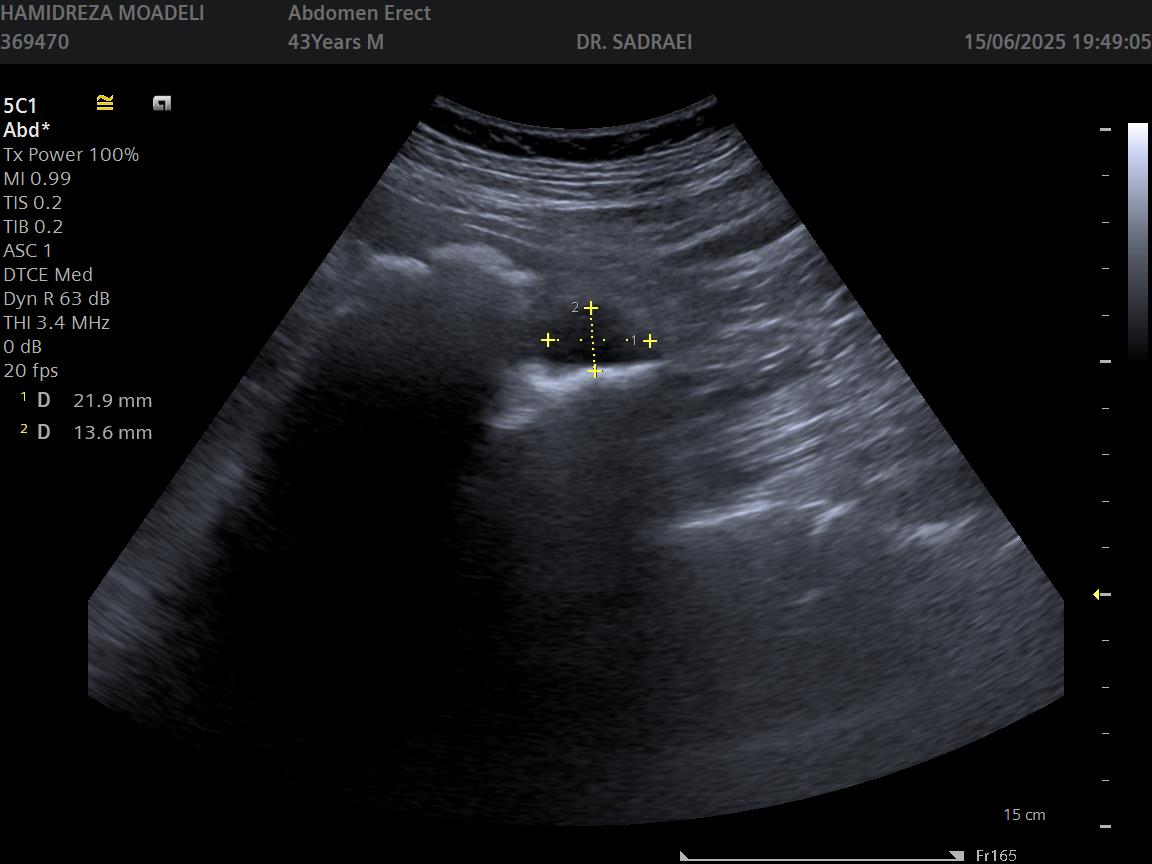

---

**[ MedGemma ]**

This is an abdominal ultrasound image.

**Description:**

The image shows a transverse view of the liver. The liver appears somewhat heterogeneous in echotexture, with some areas appearing slightly brighter (hyperechoic) and others slightly darker (hypoechoic). There is a focal area of increased echogenicity within the liver parenchyma, possibly representing a small lesion or focal fatty infiltration. The liver is generally enlarged, with the right lobe appearing larger than the left lobe. The gallbladder is not clearly visualized in this view. The spleen is visible in the left upper quadrant. The right kidney is seen in the upper right quadrant, and the left kidney is seen in the left upper quadrant. The aorta is visible in the midline. The image quality is good, with clear visualization of the liver parenchyma.

**Key Findings:**

*   **Liver:** Enlarged, heterogeneous echotexture with a focal area of increased echogenicity.
*   **Other structures:** Spleen, kidneys, aorta are visible.

**Clinical Context:**

This ultrasound is likely part of a routine abdominal evaluation. The findings of an enlarged liver with heterogeneous echotexture could be related to various conditions such as fatty liver disease, cirrhosis, or other infiltrative processes. The focal area of increased echogenicity warrants further investigation if clinically indicated.

**Disclaimer:** This is an interpretation of a single ultrasound image. A complete clinical evaluation, including patient history and other relevant investigations, is necessary for a definitive diagnosis. This interpretation should not be used for diagnostic purposes.

---

In [18]:
output = pipe(text=messages, max_new_tokens=max_new_tokens, do_sample=False)
response = output[0]["generated_text"][-1]["content"]
display(Markdown(f"---\n\n**[ User ]**\n\n{prompt}"))
display(IPImage(filename=image_filename, height=300))
display(Markdown(f"---\n\n**[ MedGemma ]**\n\n{response}\n\n---"))
     

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
!ls

drive  image.jpg  sample_data


In [29]:
!ls /content/drive/MyDrive/my_health/images/sono_1404/

133944745468597185.jpg	133944746816445808.jpg	133944748305885162.jpg
133944746303199295.jpg	133944747680676195.jpg	133944748951002993.jpg
133944746489343644.jpg	133944747788985117.jpg	133944752204281831.jpg
133944746570635489.jpg	133944747902333880.jpg
133944746673315662.jpg	133944748114112083.jpg


In [30]:
def interpret_image(image_path, prompt):
    image = Image.open(image_path)
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": system_instruction}]
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image", "image": image}
            ]
        }
    ]
    output = pipe(text=messages, max_new_tokens=max_new_tokens, do_sample=False)
    response = output[0]["generated_text"][-1]["content"]
    display(Markdown(f"---\n\n**[ User ]**\n\n{prompt}"))
    display(IPImage(filename=image_path, height=300))
    display(Markdown(f"---\n\n**[ MedGemma ]**\n\n{response}\n\n---"))

In [31]:
images_path = [f'/content/drive/MyDrive/my_health/images/sono_1404/{image_file}' for image_file in os.listdir('/content/drive/MyDrive/my_health/images/sono_1404/') if image_file.lower().endswith(('.png', '.jpg', '.jpeg'))]

In [32]:
images_path

['/content/drive/MyDrive/my_health/images/sono_1404/133944745468597185.jpg',
 '/content/drive/MyDrive/my_health/images/sono_1404/133944746570635489.jpg',
 '/content/drive/MyDrive/my_health/images/sono_1404/133944746673315662.jpg',
 '/content/drive/MyDrive/my_health/images/sono_1404/133944748305885162.jpg',
 '/content/drive/MyDrive/my_health/images/sono_1404/133944746489343644.jpg',
 '/content/drive/MyDrive/my_health/images/sono_1404/133944748114112083.jpg',
 '/content/drive/MyDrive/my_health/images/sono_1404/133944747788985117.jpg',
 '/content/drive/MyDrive/my_health/images/sono_1404/133944747902333880.jpg',
 '/content/drive/MyDrive/my_health/images/sono_1404/133944746303199295.jpg',
 '/content/drive/MyDrive/my_health/images/sono_1404/133944752204281831.jpg',
 '/content/drive/MyDrive/my_health/images/sono_1404/133944747680676195.jpg',
 '/content/drive/MyDrive/my_health/images/sono_1404/133944748951002993.jpg',
 '/content/drive/MyDrive/my_health/images/sono_1404/133944746816445808.jpg']

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944745468597185.jpg


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


---

**[ User ]**

Describe these Sono iamges

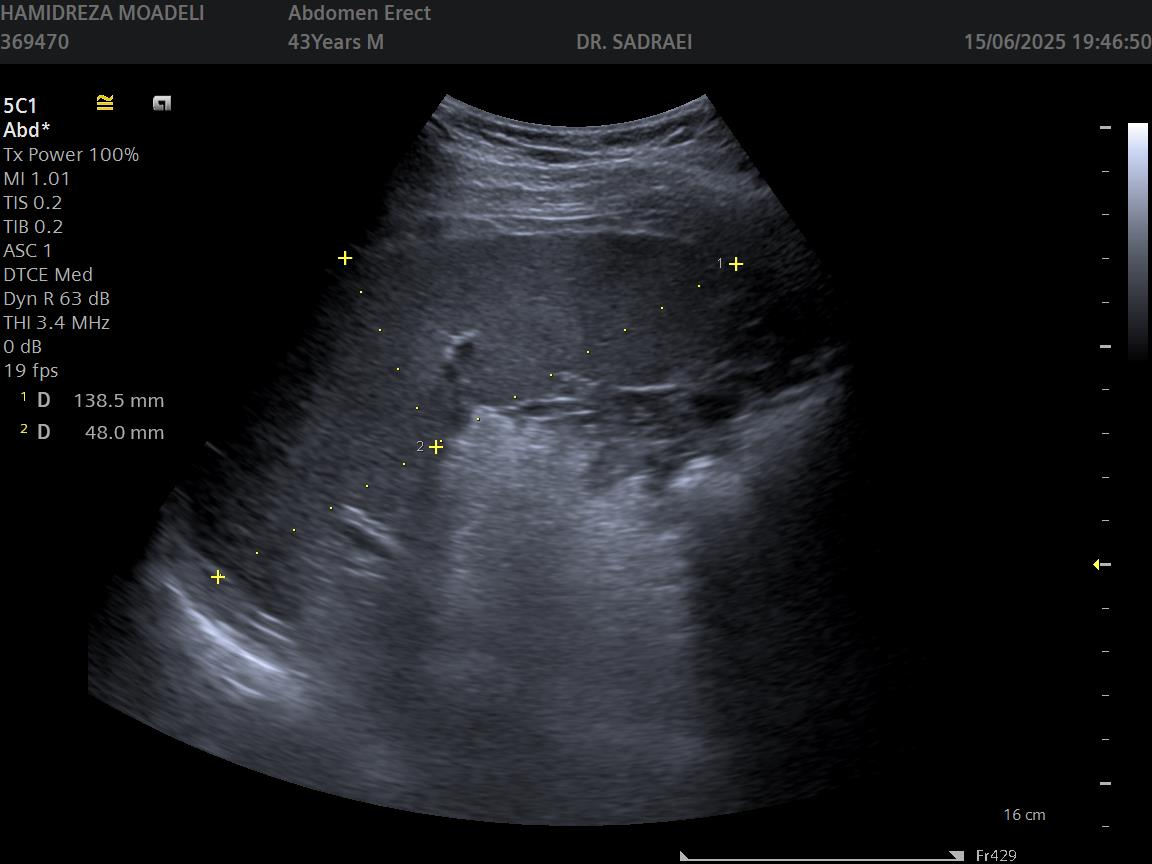

---

**[ MedGemma ]**

This is a grayscale ultrasound image of the liver. The liver appears enlarged, with a large area of hypoechoic (darker) material occupying a significant portion of the right lobe. There are also some hyperechoic (brighter) areas within the liver parenchyma. The overall echogenicity of the liver parenchyma is somewhat heterogeneous. The image shows the liver in the right upper quadrant of the abdomen. The right lobe of the liver is visible, along with parts of the left lobe. The gallbladder is not clearly visualized in this view. The right kidney is partially visible in the upper right quadrant. The right adrenal gland is also partially visible. The image quality is good, and the anatomical structures are well-defined. The measurement scale indicates the liver is approximately 16 cm in length.

**Key findings:**

*   **Enlarged liver:** The liver appears significantly enlarged.
*   **Hypoechoic lesion:** A large area of hypoechoic material is present within the liver, likely representing a lesion or abnormal tissue.
*   **Heterogeneous echogenicity:** The liver parenchyma shows some variation in echogenicity.

**Clinical context:**

This ultrasound finding of an enlarged liver with a large hypoechoic lesion would warrant further investigation, such as a contrast-enhanced CT scan or MRI, to determine the nature of the lesion. The enlarged liver could be due to various causes, including fatty liver disease, cirrhosis, or other infiltrative processes.

**Disclaimer:** This is an interpretation of a single ultrasound image. A definitive diagnosis requires clinical correlation and potentially further imaging studies.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944745468597185.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944746570635489.jpg


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

Describe these Sono iamges

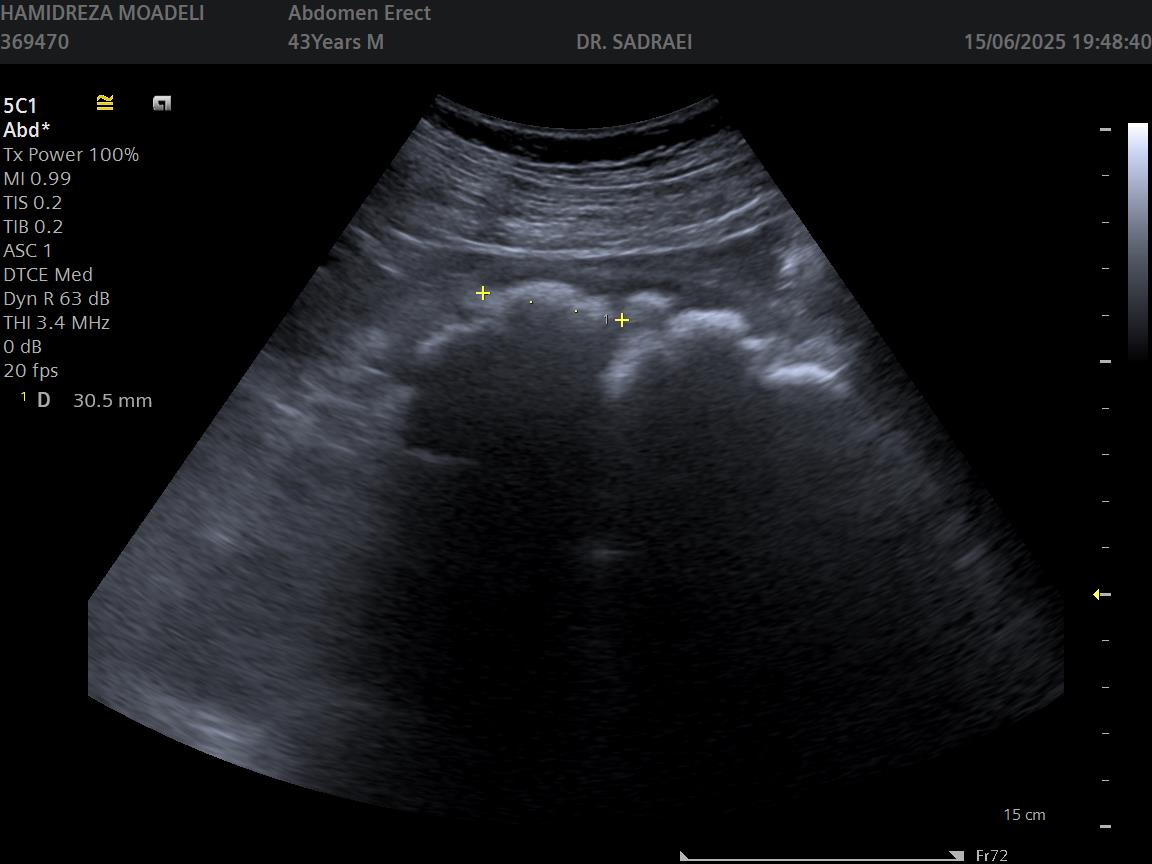

---

**[ MedGemma ]**

This is an abdominal ultrasound image. The image shows a transverse view of the liver.

The liver appears enlarged, with a large mass occupying the right lobe. The mass is hypoechoic (darker than the surrounding liver tissue). There are some small hyperechoic (brighter) foci within the mass, which could represent small cysts or other structures. The liver parenchyma surrounding the mass appears relatively normal.

The image quality is good, and the structures are well-defined. The measurement scale indicates the liver is approximately 15 cm in length.

The patient is a 43-year-old male.

**Key findings:**

*   **Enlarged liver:** The liver appears significantly enlarged.
*   **Mass in the right lobe:** A large hypoechoic mass is present in the right lobe of the liver.
*   **Small hyperechoic foci:** Small bright spots are visible within the mass.

**Clinical correlation:** This finding requires further investigation, such as contrast-enhanced CT or MRI, to characterize the mass further. The enlarged liver could be due to various causes, including cirrhosis, fatty liver disease, or infiltrative processes. The mass could be a cyst, hemangioma, or malignancy.

**Disclaimer:** This is an interpretation of a single ultrasound image. A definitive diagnosis requires clinical context and further imaging or laboratory tests.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944746570635489.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944746673315662.jpg


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

Describe these Sono iamges

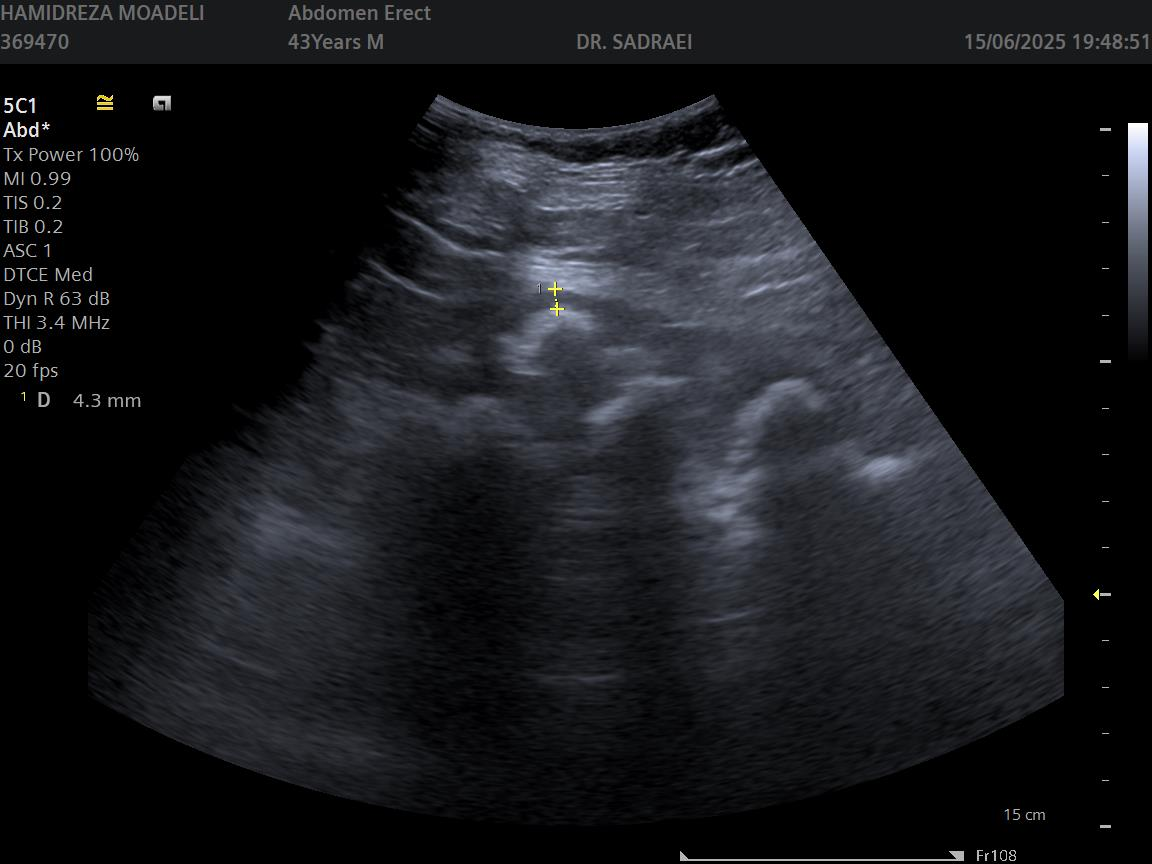

---

**[ MedGemma ]**

This is a grayscale ultrasound image of the abdomen. The image shows a cross-sectional view of the body, likely the liver, given the characteristic echogenicity and shape.

Here's a breakdown of the image:

*   **Image Quality:** The image appears to be a standard grayscale ultrasound. The resolution is adequate, allowing visualization of the structures within the field of view.
*   **Anatomy:** The image shows a large, somewhat irregular-shaped structure occupying a significant portion of the field of view. This structure has a complex internal architecture with multiple internal echoes and varying levels of echogenicity. This is consistent with the appearance of the liver.
*   **Key Features:** There is a small, bright structure with a crosshair marker superimposed on the image, likely indicating a specific point of interest or a lesion within the liver.
*   **Other Structures:** The surrounding tissue appears relatively homogeneous, although some minor variations in echogenicity are visible.
*   **Scale:** The scale bar at the bottom indicates a measurement of 15 cm, suggesting the field of view covers a significant portion of the abdomen.

**Interpretation:**

The image shows a cross-sectional view of the liver. The liver appears somewhat heterogeneous in echogenicity, which can be normal or indicate various conditions. The small bright structure with the crosshair marker is likely a focal lesion or area of interest within the liver parenchyma.

**Disclaimer:** This is a description of the image based on visual analysis. A definitive diagnosis requires clinical context, correlation with other imaging modalities, and interpretation by a qualified radiologist.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944746673315662.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944748305885162.jpg


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

Describe these Sono iamges

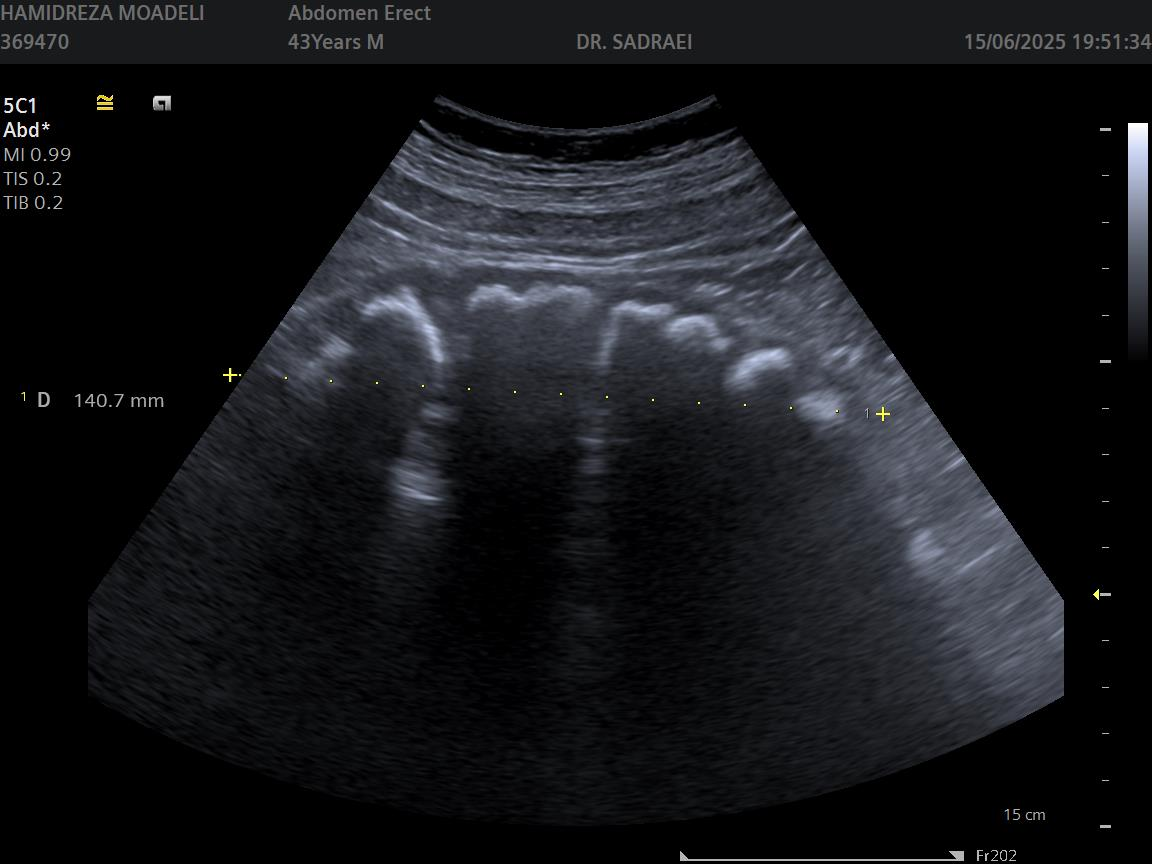

---

**[ MedGemma ]**

This is an abdominal ultrasound image.

**Key Findings:**

*   **Large Bowel:** The image shows a large, dilated bowel loop occupying a significant portion of the abdominal cavity. The lumen appears very wide, consistent with a large bowel obstruction or significant dilation.
*   **Wall Thickness:** The wall of the dilated bowel loop appears thickened, which can be a sign of inflammation, edema, or potentially a mass within the bowel wall.
*   **Other Structures:** The liver, spleen, and other abdominal organs are not clearly visualized in this view, which is focused on the bowel.
*   **Measurement:** A measurement marker indicates a diameter of 140.7 mm along the long axis of the dilated bowel loop.

**Interpretation:**

The image suggests a significant dilation of the large bowel, potentially due to a large bowel obstruction (e.g., adhesions, tumor, volvulus) or severe constipation leading to functional obstruction. The thickened bowel wall raises concern for associated inflammation or other pathology.

**Clinical Context:**

This finding would typically warrant further investigation, such as a CT scan or colonoscopy, to determine the underlying cause and severity.

**Disclaimer:** This is an interpretation of a single ultrasound image. A complete clinical evaluation, including patient history and other imaging modalities, is necessary for accurate diagnosis and management.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944748305885162.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944746489343644.jpg


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

Describe these Sono iamges

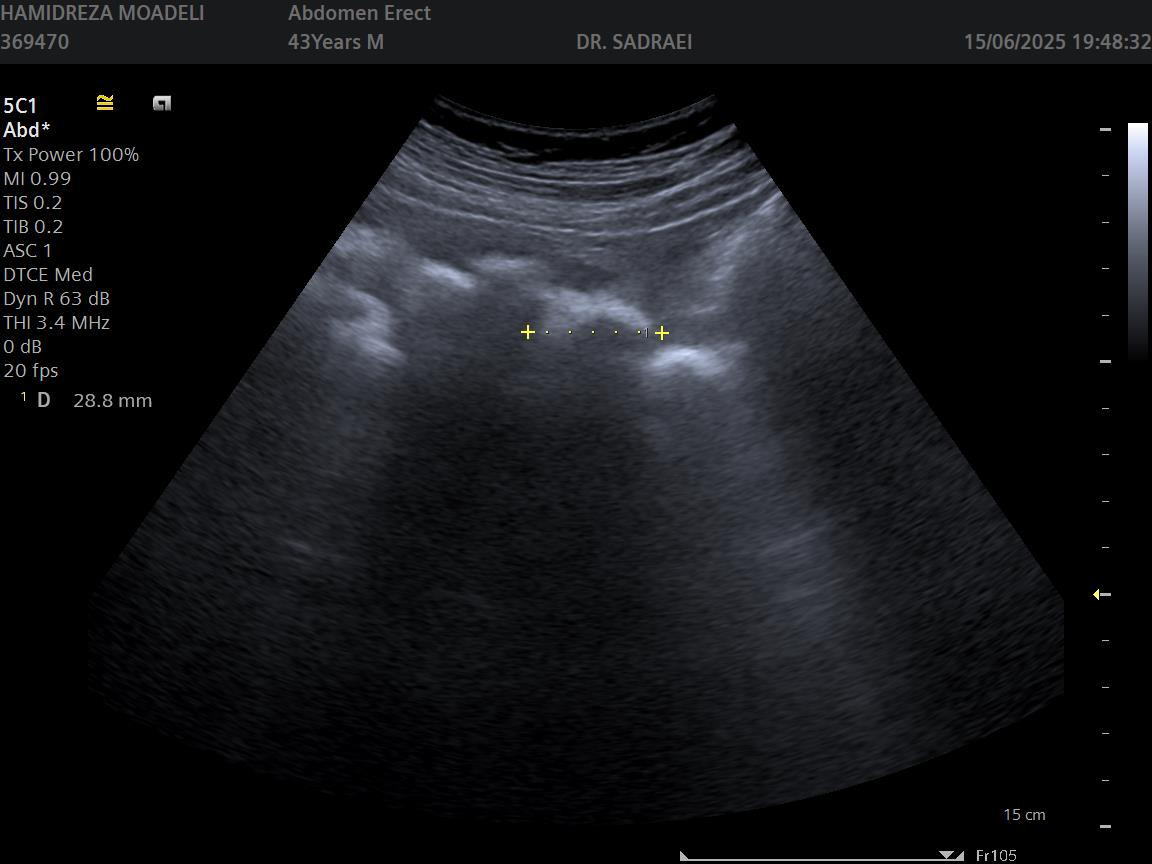

---

**[ MedGemma ]**

This is a grayscale ultrasound image of the abdomen. The image shows a cross-sectional view of the body, likely focusing on the pelvic region given the depth of the structures visualized.

Key features visible in the image include:

*   **Bowel loops:** There are several loops of bowel seen within the abdomen.
*   **Fluid-filled structures:** The bowel loops appear somewhat distended, suggesting they contain fluid or gas.
*   **Anterior abdominal wall:** The anterior abdominal wall is visible.
*   **Other structures:** Other abdominal structures are partially visible but are obscured by the bowel loops.

The image quality is adequate, but the resolution is limited by the grayscale nature of the ultrasound. The specific clinical context (patient's age, symptoms, reason for the ultrasound) would be needed to interpret the findings accurately.

**Disclaimer:** I am an AI and cannot provide medical diagnoses. This description is based on the visual information in the image. A qualified healthcare professional should interpret the image in the context of the patient's clinical presentation.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944746489343644.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944748114112083.jpg


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

Describe these Sono iamges

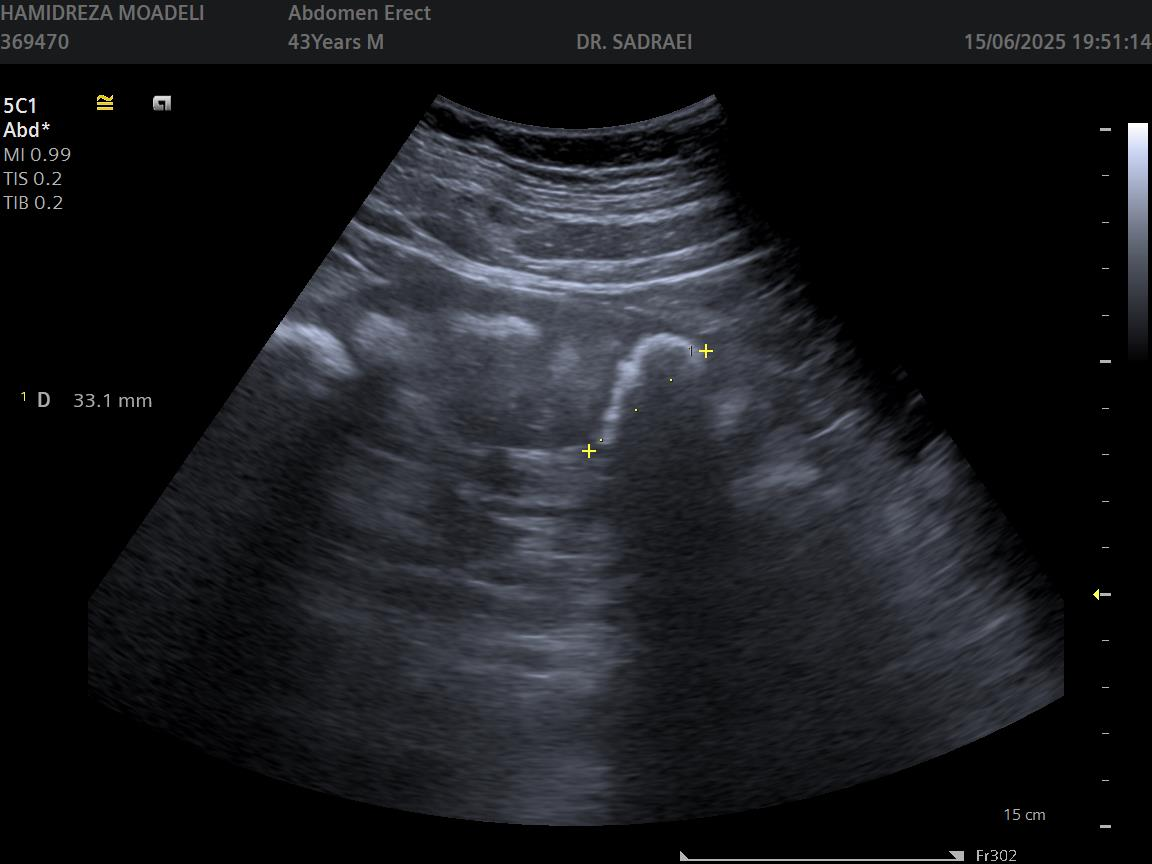

---

**[ MedGemma ]**

This is a grayscale ultrasound image of the abdomen. The image shows a transverse view of the liver.

Key features visible in the image:

*   **Liver:** The liver appears as a large, homogenous, hypoechoic (darker) structure occupying a significant portion of the image.
*   **Biliary Ducts:** The common bile duct is visible as a slightly hyperechoic (brighter) structure running across the mid-abdomen.
*   **Other Structures:** The gallbladder is not clearly visible in this view. The spleen and kidneys are not well visualized in this transverse view.
*   **Measurement:** A measurement marker indicates "33.1 mm", likely representing the diameter of the liver or a specific structure within it.
*   **Image Quality:** The image quality is generally good, although there is some artifact due to the ultrasound gel and the patient's body.

**Interpretation:**

This is a standard transverse view of the liver. Without clinical context or comparison images, it's difficult to provide a definitive diagnosis. However, the liver appears generally normal in terms of echogenicity and structure based on this single image. Further evaluation would require correlation with the patient's history, physical examination, and potentially other imaging modalities.

**Disclaimer:** This is an interpretation of a single ultrasound image. A complete medical evaluation requires a radiologist's full assessment, including patient history, physical exam, and potentially other imaging studies.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944748114112083.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944747788985117.jpg


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

Describe these Sono iamges

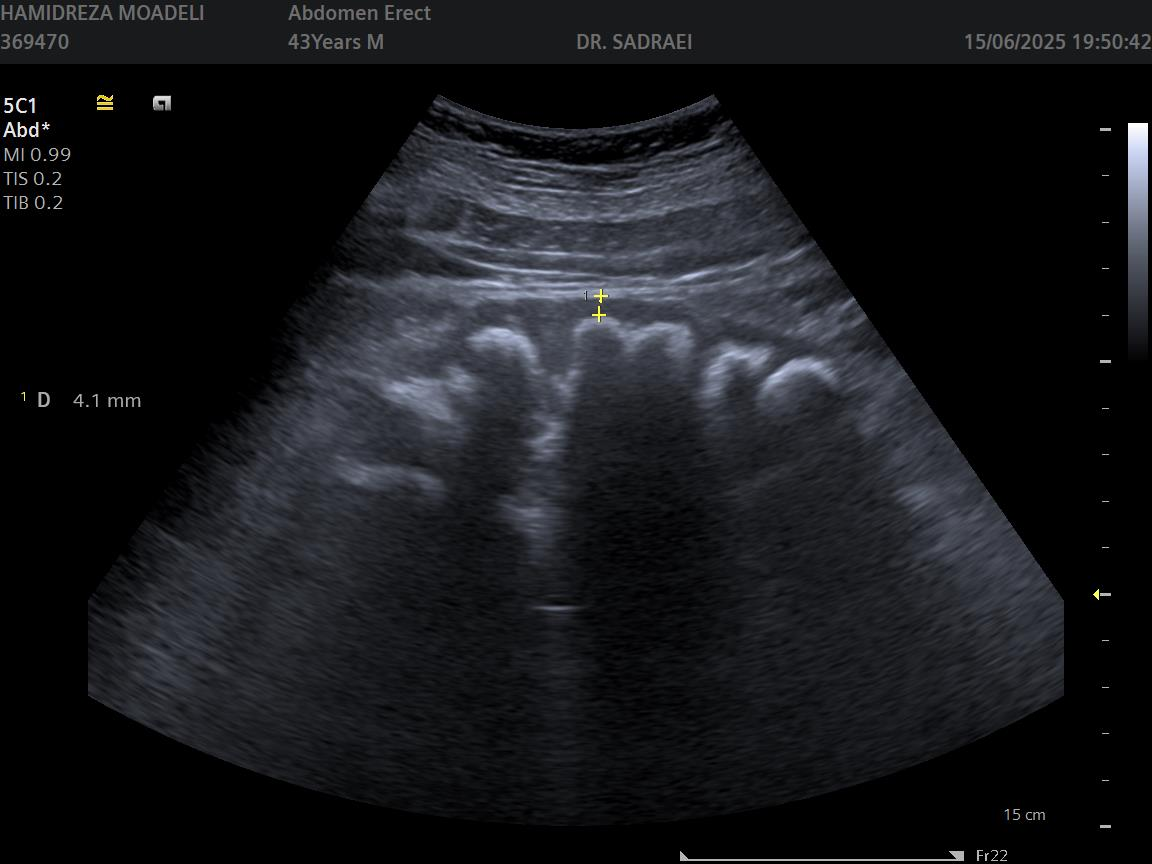

---

**[ MedGemma ]**

This is a grayscale ultrasound image of the abdomen. The image shows a cross-sectional view of the abdominal wall.

Key features visible in the image:

*   **Abdominal Wall:** The image displays the layers of the abdominal wall, including the subcutaneous fat and the muscle layers.
*   **Muscle Layers:** The image shows the superficial and deep muscle layers of the abdominal wall.
*   **Fat:** There is visible subcutaneous fat.
*   **Other Structures:** The image shows the general structure of the abdominal wall.

The image appears to be a standard abdominal ultrasound scan. The quality seems adequate for visualization of the abdominal wall structures.

**Disclaimer:** I am an AI and cannot provide medical diagnoses. This description is based on the visual information in the image. A qualified healthcare professional should interpret the image in the context of the patient's clinical history and other relevant information.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944747788985117.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944747902333880.jpg


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

Describe these Sono iamges

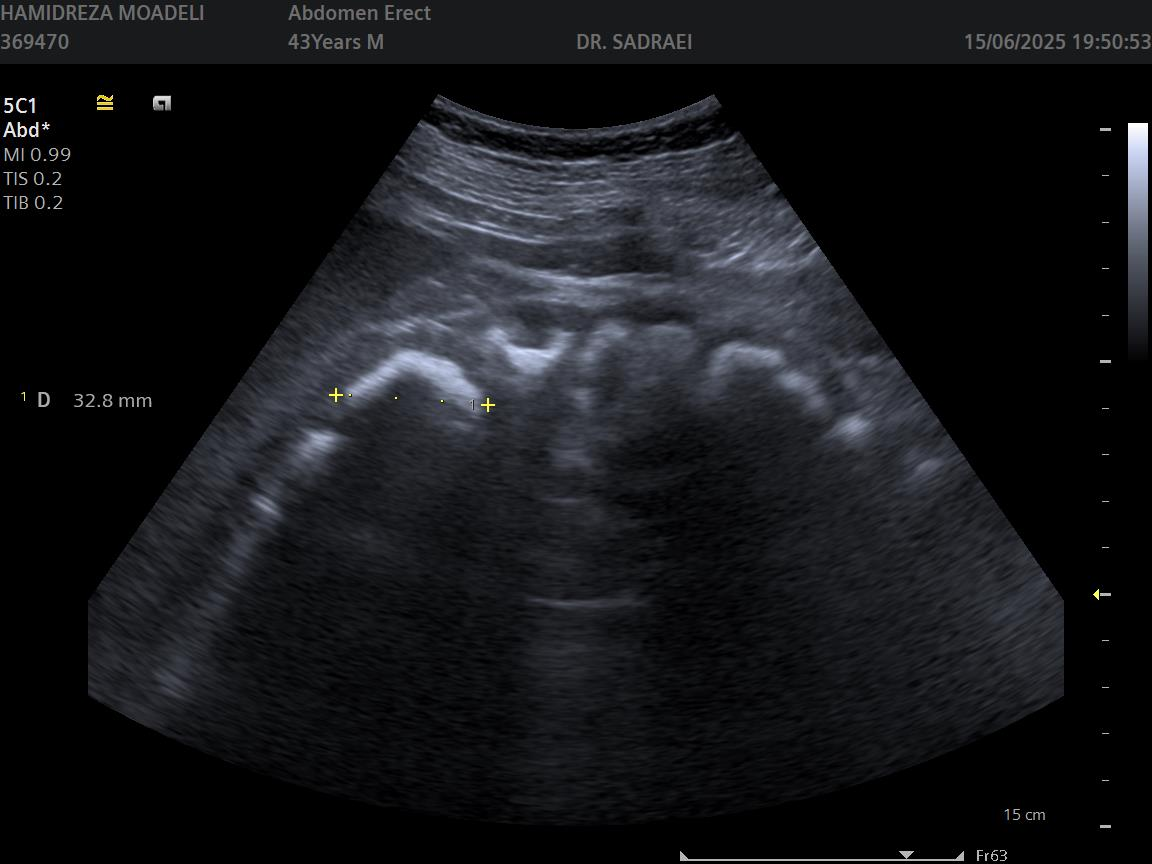

---

**[ MedGemma ]**

This is a grayscale ultrasound image of the abdomen. The image shows a transverse view of the abdominal wall.

Key features visible in the image:

*   **Abdominal Wall:** The image displays the anterior abdominal wall, which appears somewhat thickened and irregular in texture.
*   **Muscle Tissue:** Underlying the abdominal wall, there is a layer of muscle tissue, which appears somewhat hypoechoic (darker) compared to the surrounding structures.
*   **Possible Subcutaneous Fat:** There is a layer of subcutaneous fat visible, which appears as a hyperechoic (brighter) layer.
*   **Other Structures:** The image shows some internal structures, but they are not clearly defined due to the focus being on the abdominal wall.
*   **Measurement:** A measurement marker is visible, indicating a depth of 32.8 mm.

**Interpretation:**

The image shows a transverse view of the anterior abdominal wall. The wall appears somewhat thickened and irregular. This could be related to various factors, including obesity, post-surgical changes, or other underlying conditions. Without clinical context, it's difficult to provide a definitive diagnosis.

**Disclaimer:** This is a description of the ultrasound image based on visual analysis. It is not a medical diagnosis. A qualified healthcare professional should interpret the image in the context of the patient's clinical history and other relevant investigations.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944747902333880.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944746303199295.jpg


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

Describe these Sono iamges

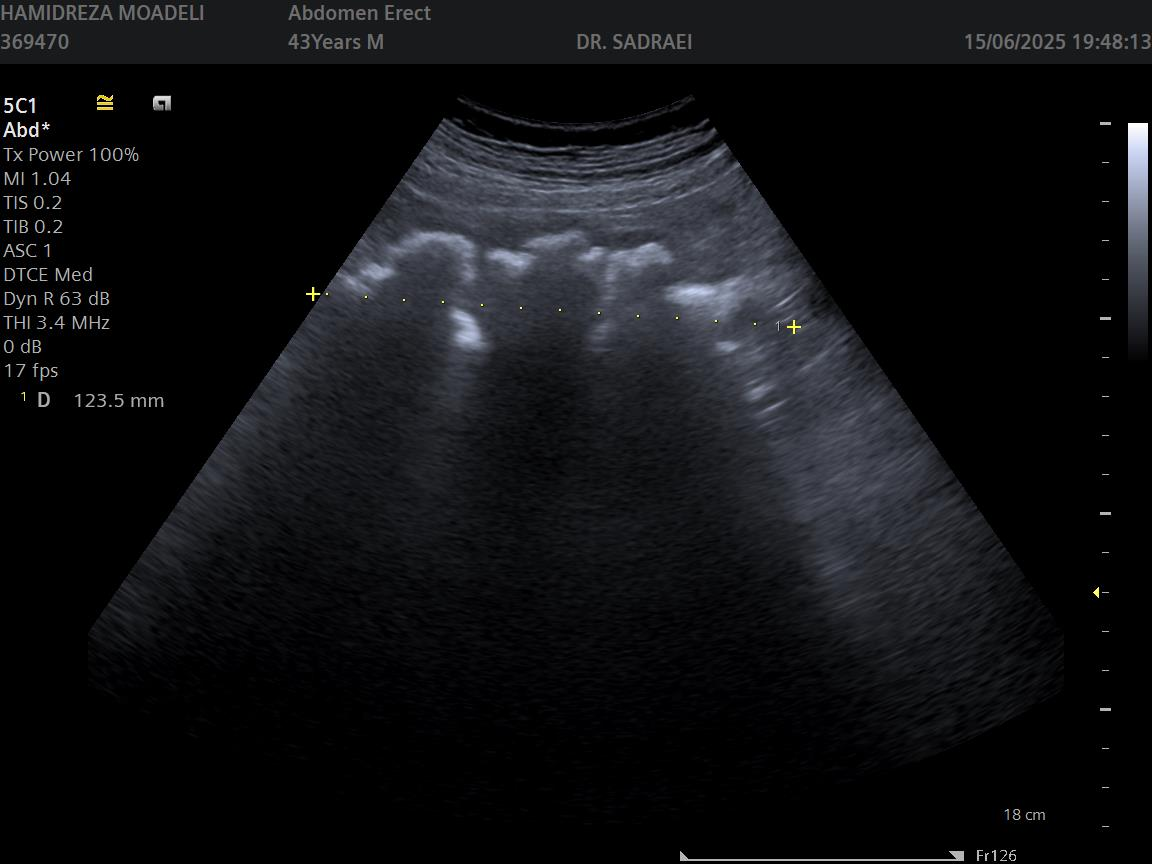

---

**[ MedGemma ]**

This is a grayscale ultrasound image of the abdomen, specifically focusing on the liver.

**Key features:**

*   **Liver:** The liver appears as a large, homogenous, hyperechoic (bright) structure occupying the majority of the image.
*   **Focal Lesion:** There is a well-defined, hypoechoic (darker) lesion within the liver parenchyma. It appears somewhat rounded or oval.
*   **Other Structures:** The gallbladder and other abdominal structures are not clearly visible in this field of view.
*   **Measurement:** A measurement marker is present, indicating a size of 123.5 mm.
*   **Image Quality:** The image quality is generally good, with clear visualization of the liver parenchyma.

**Interpretation:**

The image shows a focal hypoechoic lesion within the liver. Further characterization would require additional imaging (e.g., contrast-enhanced ultrasound, CT, or MRI) to determine the nature of this lesion (e.g., hemangioma, cyst, focal nodular hyperplasia, malignancy).

**Disclaimer:** This is a description of the image based on visual analysis. A definitive diagnosis requires clinical correlation and potentially further imaging studies.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944746303199295.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944752204281831.jpg


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

Describe these Sono iamges

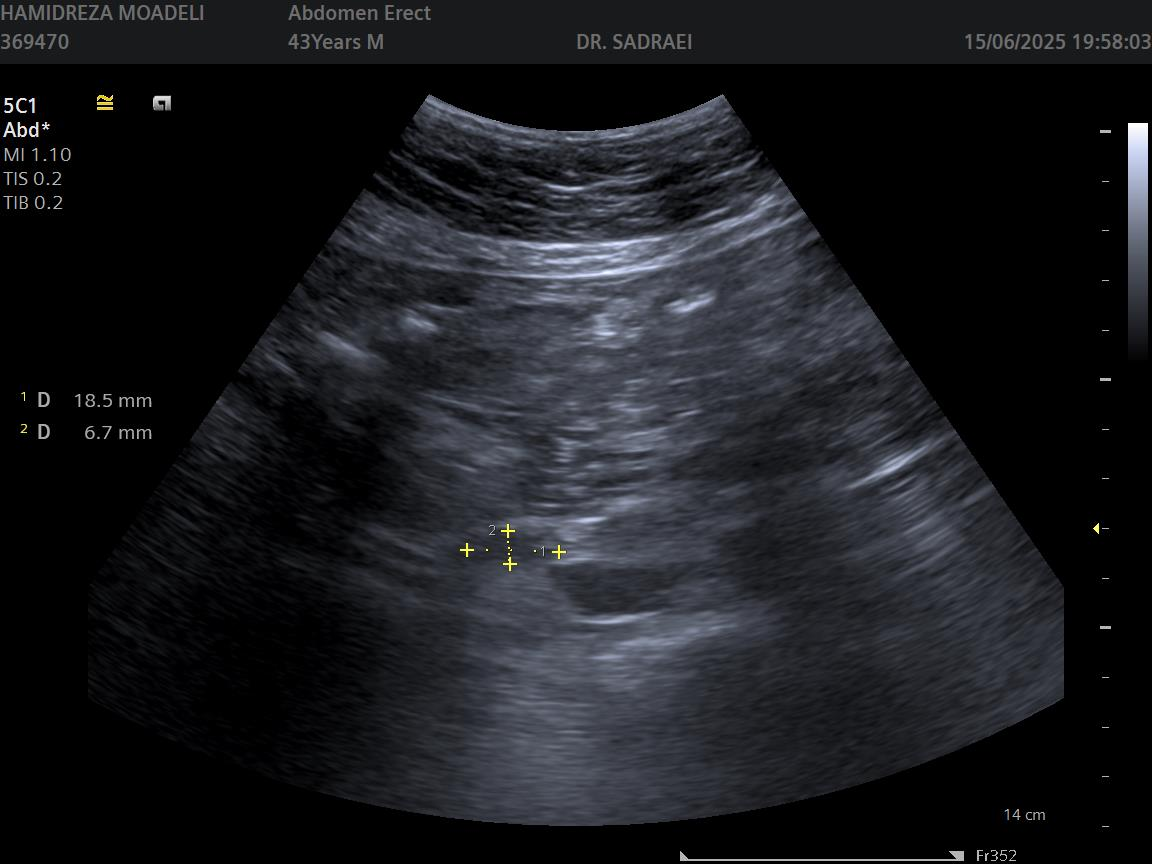

---

**[ MedGemma ]**

This is an abdominal ultrasound image.

**Description:**

The image shows a transverse view of the abdomen. The liver appears enlarged, with a diameter of approximately 18.5 cm in the right lobe and 6.7 cm in the left lobe. The liver parenchyma is homogeneous in echotexture. The gallbladder is not clearly visualized. The spleen is not clearly visualized. The kidneys are not clearly visualized. The aorta is not clearly visualized. The bowel loops are not clearly visualized. There is a small amount of free fluid in the abdomen.

**Key Findings:**

*   **Enlarged Liver:** The liver appears significantly enlarged, measuring approximately 18.5 cm in the right lobe.
*   **Free Fluid:** A small amount of free fluid is present in the abdomen.

**Clinical Context:**

This ultrasound finding of an enlarged liver could be related to various conditions, including liver disease (e.g., cirrhosis, fatty liver disease), portal hypertension, or other systemic conditions. The presence of free fluid could indicate ascites, which is often associated with liver disease or other abdominal pathologies.

**Disclaimer:** This is a description of the ultrasound image based on the provided information. A definitive diagnosis requires clinical correlation and potentially further imaging or laboratory tests. This description is not a substitute for professional medical advice.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944752204281831.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944747680676195.jpg


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

Describe these Sono iamges

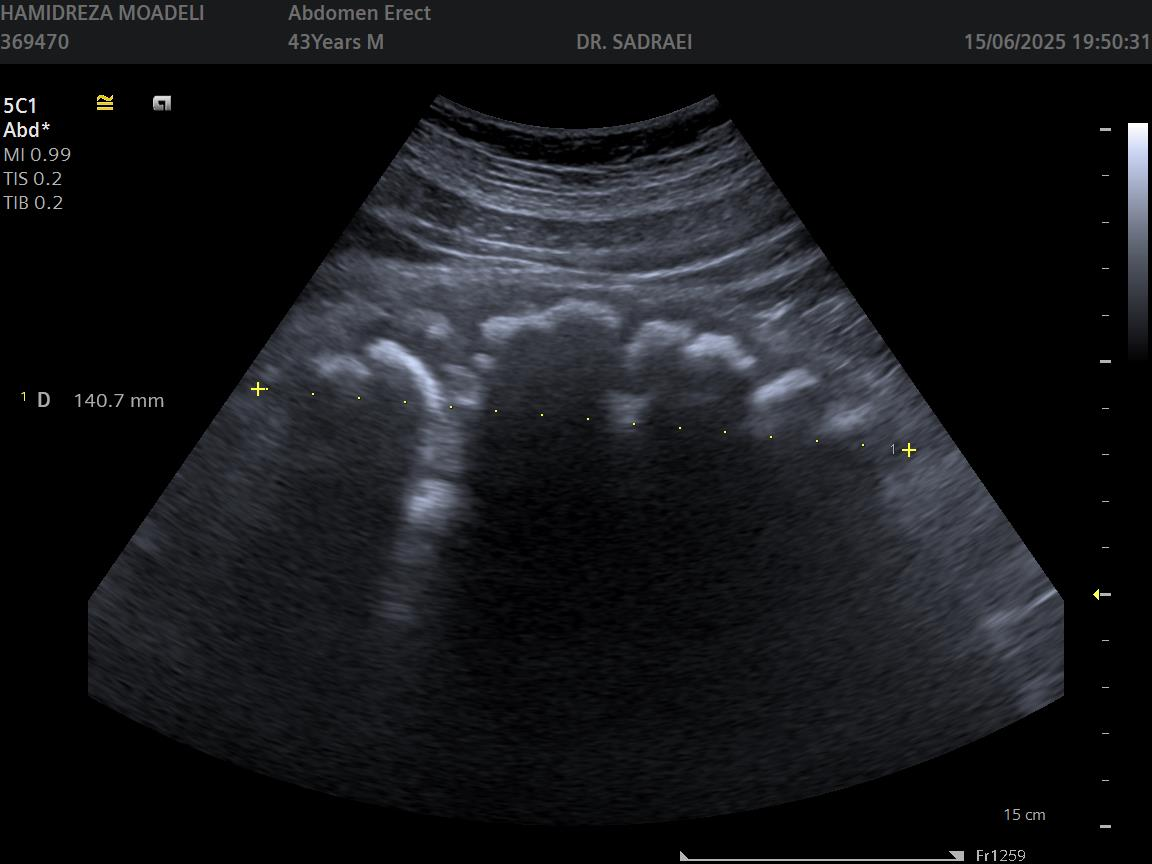

---

**[ MedGemma ]**

This is a grayscale ultrasound image of the abdomen. The image shows a transverse view of the liver.

**Key features:**

*   **Liver:** The liver appears enlarged, with a rounded contour.
*   **Hepatomegaly:** The liver measures approximately 140.7 mm in the transverse dimension, which is considered enlarged (normal liver size is typically around 12-15 cm in adults).
*   **Texture:** The liver parenchyma appears somewhat heterogeneous, with some areas appearing slightly hyperechoic (brighter) and others slightly hypoechoic (darker). This could suggest underlying pathology, but further evaluation is needed.
*   **Other structures:** The gallbladder, spleen, and kidneys are not clearly visualized in this single image.

**Interpretation:**

The image shows hepatomegaly (enlarged liver). The heterogeneous texture might indicate underlying liver disease, such as fatty liver, cirrhosis, or other infiltrative processes.

**Clinical Correlation:**

This finding should be correlated with the patient's clinical history, physical examination, and laboratory results. Further imaging (e.g., contrast-enhanced CT or MRI) or serological tests may be necessary to determine the underlying cause of the hepatomegaly.

**Disclaimer:** This is an interpretation of a single ultrasound image. A complete clinical evaluation is required for diagnosis and management.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944747680676195.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944748951002993.jpg


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

Describe these Sono iamges

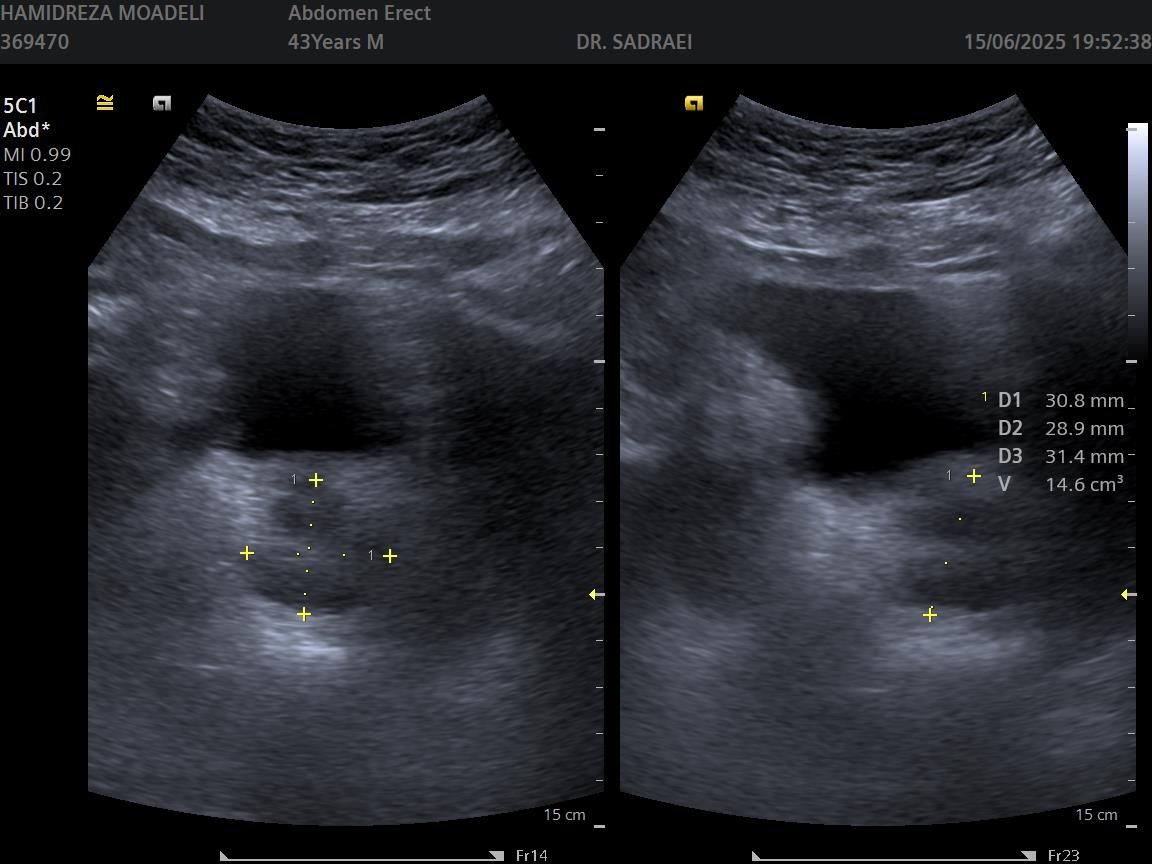

---

**[ MedGemma ]**

These are two ultrasound images of the pelvis, likely focusing on the uterus and surrounding structures.

**Image Description:**

*   **Patient:** 43-year-old male (indicated by "43Years M").
*   **Procedure:** Abdomen Erect (suggesting the patient was standing).
*   **Date:** 15/06/2025.
*   **Technique:** Transverse (cross-sectional) view.
*   **Findings:**
    *   The images show a retroverted uterus, meaning the fundus (top part) is tilted backward.
    *   There appears to be a mass or cystic structure within the uterine body, possibly representing a fibroid or other pelvic pathology.
    *   The endometrium (lining of the uterus) is not clearly visualized in these transverse views, but the mass obscures its normal appearance.
    *   The ovaries are not clearly visualized in these specific images.
    *   The bladder is partially visible at the bottom of the images.
    *   The measurements provided (D1, D2, D3, V) likely refer to the dimensions of the mass or other structures within the field of view.

**Interpretation:**

The presence of a mass within the uterus in a 43-year-old male suggests a possible uterine pathology, such as a fibroid, adenomyosis, or other pelvic mass. Further evaluation, potentially including a pelvic MRI or further ultrasound focusing on the mass, would be needed for a definitive diagnosis. The retroverted uterus is a common anatomical variation.

**Important Note:** This is a description based on the provided images alone. A complete clinical evaluation, including patient history and potentially other imaging modalities, is necessary for accurate diagnosis and management.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944748951002993.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944746816445808.jpg


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


---

**[ User ]**

Describe these Sono iamges

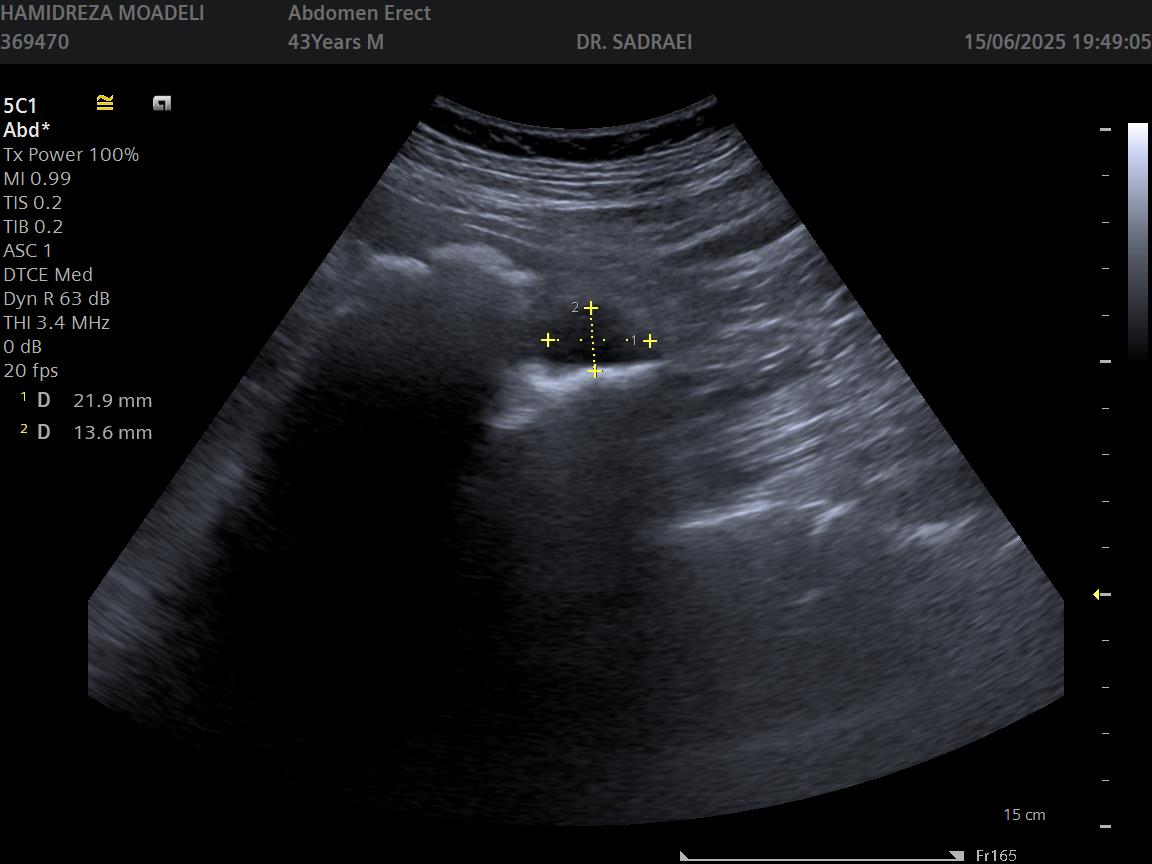

---

**[ MedGemma ]**

This is an abdominal ultrasound image.

**Description:**

The image shows a transverse view of the liver. The liver appears somewhat heterogeneous in echotexture, with some areas appearing slightly brighter (hyperechoic) and others slightly darker (hypoechoic). There is a focal area of increased echogenicity within the liver parenchyma, possibly representing a small lesion or focal fatty infiltration. The liver is generally enlarged, with the right lobe appearing larger than the left lobe. The gallbladder is not clearly visualized in this view. The spleen is visible in the left upper quadrant. The right kidney is seen in the upper right quadrant, and the left kidney is seen in the left upper quadrant. The aorta is visible in the midline. The image quality is good, with clear visualization of the liver parenchyma.

**Key Findings:**

*   **Liver:** Enlarged, heterogeneous echotexture with a focal area of increased echogenicity.
*   **Other structures:** Spleen, kidneys, aorta are visible.

**Clinical Context:**

This ultrasound is likely part of a routine abdominal evaluation. The findings of an enlarged liver with heterogeneous echotexture could be related to various conditions such as fatty liver disease, cirrhosis, or other infiltrative processes. The focal area of increased echogenicity warrants further investigation if clinically indicated.

**Disclaimer:** This is an interpretation of a single ultrasound image. A complete clinical evaluation, including patient history and other relevant investigations, is necessary for a definitive diagnosis. This interpretation should not be used for diagnostic purposes.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944746816445808.jpg




In [34]:
for image_path in images_path:
    print(f"Processed image: {image_path}")
    interpret_image(image_path, prompt)
    print(f"Finished processing image: {image_path}\n\n")


In [67]:
prompt = "Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary"  # @param {type: "string"}


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944745468597185.jpg


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


---

**[ User ]**

Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary

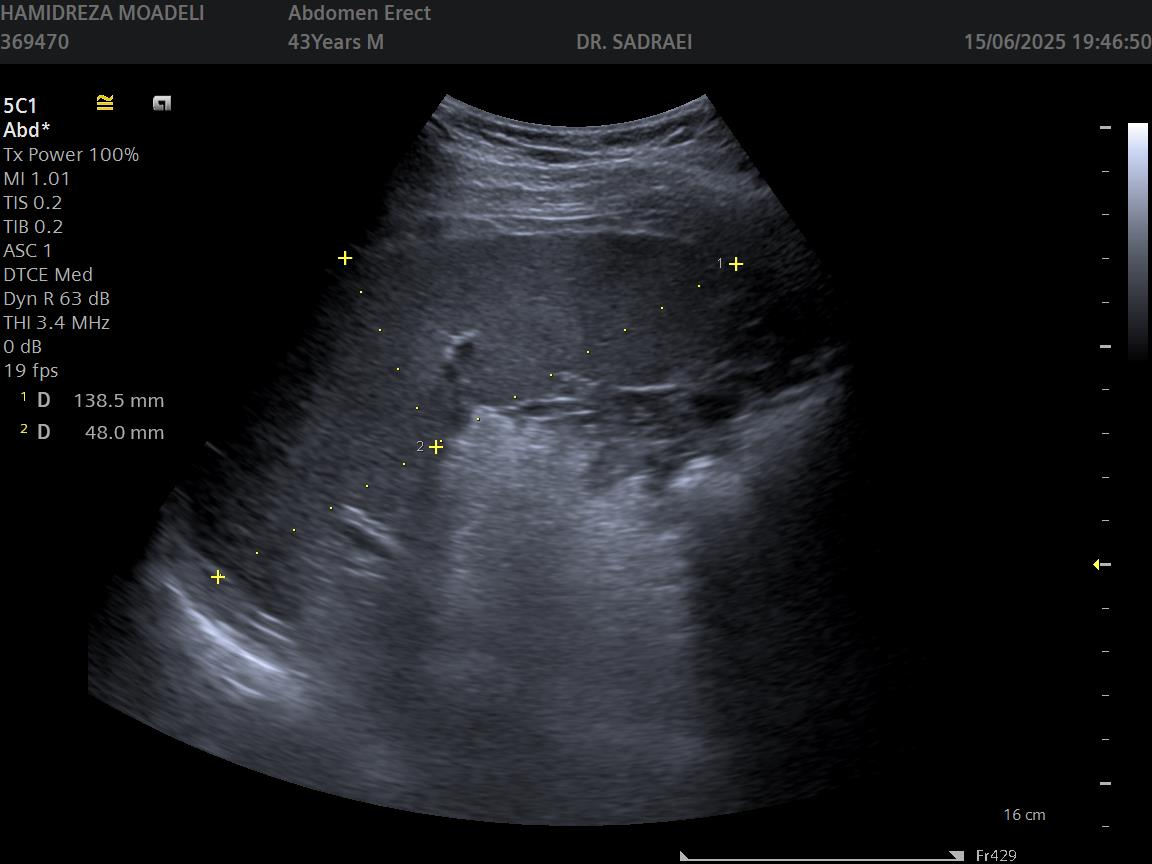

---

**[ MedGemma ]**

Based on the provided Sono image, here are the main measurements indicated by 'D' in mm:

*   **48.0 mm:** This measurement is located in the right side of the image, likely representing the **liver**.
*   **138.5 mm:** This measurement is located in the left side of the image, likely representing the **liver**.

**Summary:**

The image shows a transverse view of the liver. The liver appears enlarged, with measurements of approximately 48.0 mm and 138.5 mm. These measurements likely represent the **liver dimensions** in the axial plane.

---

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944745468597185.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944746570635489.jpg


---

**[ User ]**

Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary

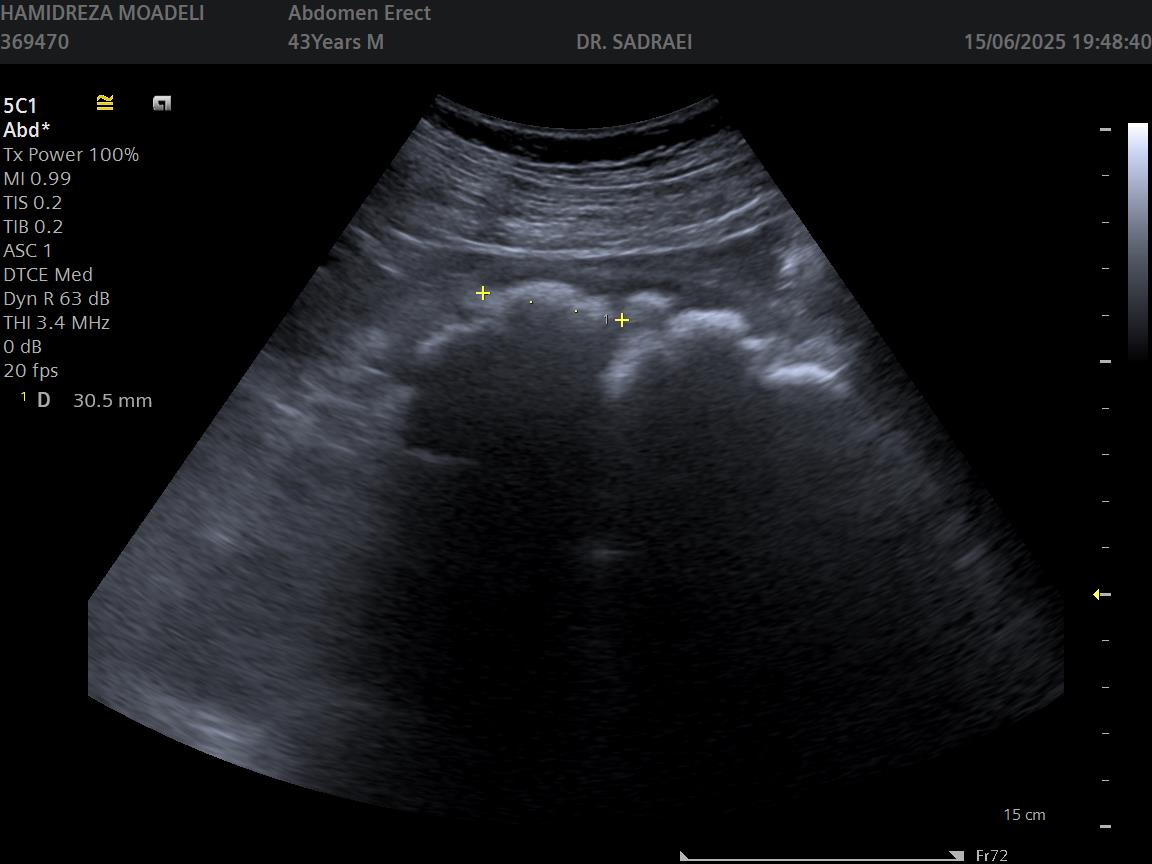

---

**[ MedGemma ]**

Based on the provided Sono image, here are the main measurements indicated by 'D' in mm:

*   **30.5 mm:** This measurement is located in the lower right quadrant of the image, near the transducer. It appears to be a measurement of the depth of the transducer or the distance from the transducer to the tissue.

**Guess what these measurements represent:**

*   **30.5 mm:** This likely represents the depth of the transducer from the skin surface to the tissue being imaged, or potentially the distance from the transducer to the target structure.

**Summary:**

The image shows a transverse view of the abdomen. The measurement of 30.5 mm is likely related to the transducer depth or distance from the transducer to the tissue. The image appears to be focused on the lower abdomen, possibly the pelvis or the lower part of the large bowel.

---

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944746570635489.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944746673315662.jpg


---

**[ User ]**

Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary

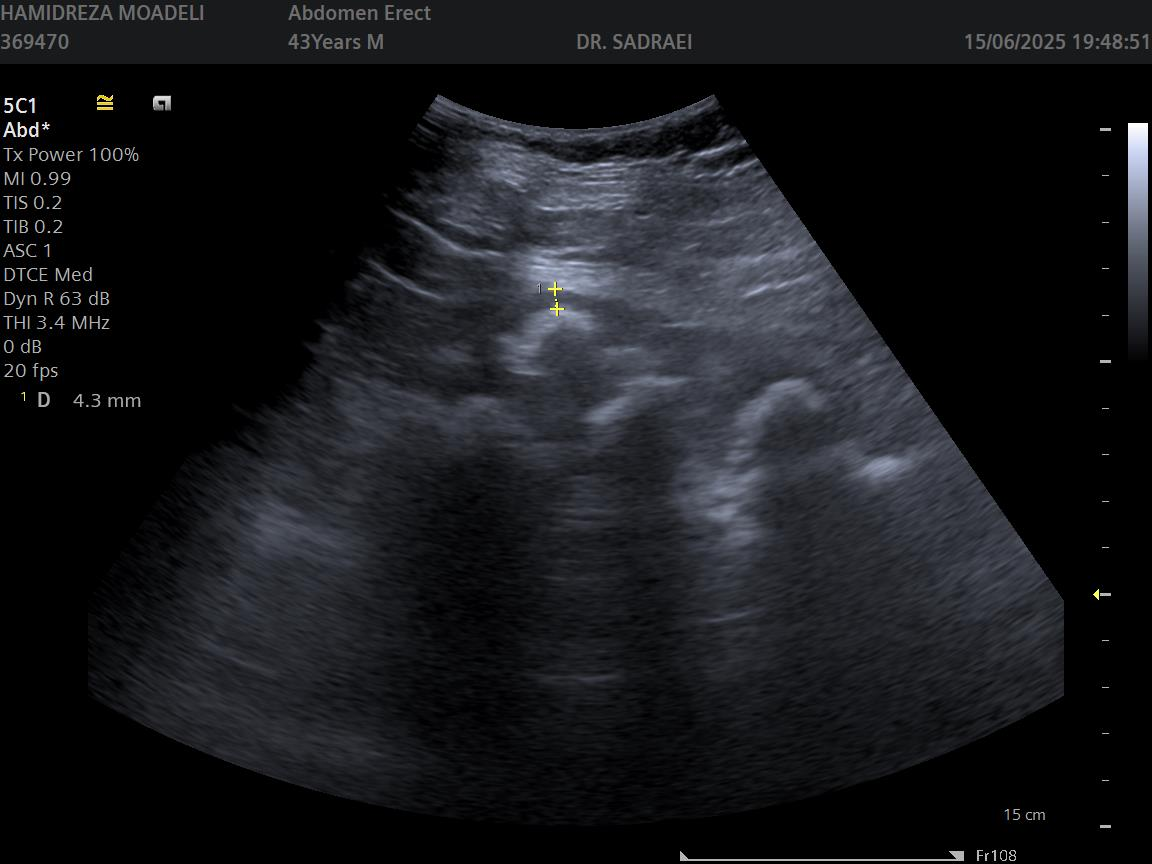

---

**[ MedGemma ]**

Based on the provided Sono image, here are the main measurements indicated by 'D' in mm:

*   **4.3 mm:** This measurement is located near the center of the image, slightly to the left. It appears to be a small, focal measurement.

**Interpretation:**

*   **4.3 mm:** This measurement likely represents a small focal lesion or abnormality within the liver parenchyma, possibly a cyst, hemangioma, or other focal lesion.

**Summary:**

The image shows a transverse view of the abdomen, likely the liver. There is a focal measurement of 4.3 mm in the liver parenchyma. Further characterization would be needed to determine the exact nature of this finding.

---

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944746673315662.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944748305885162.jpg


---

**[ User ]**

Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary

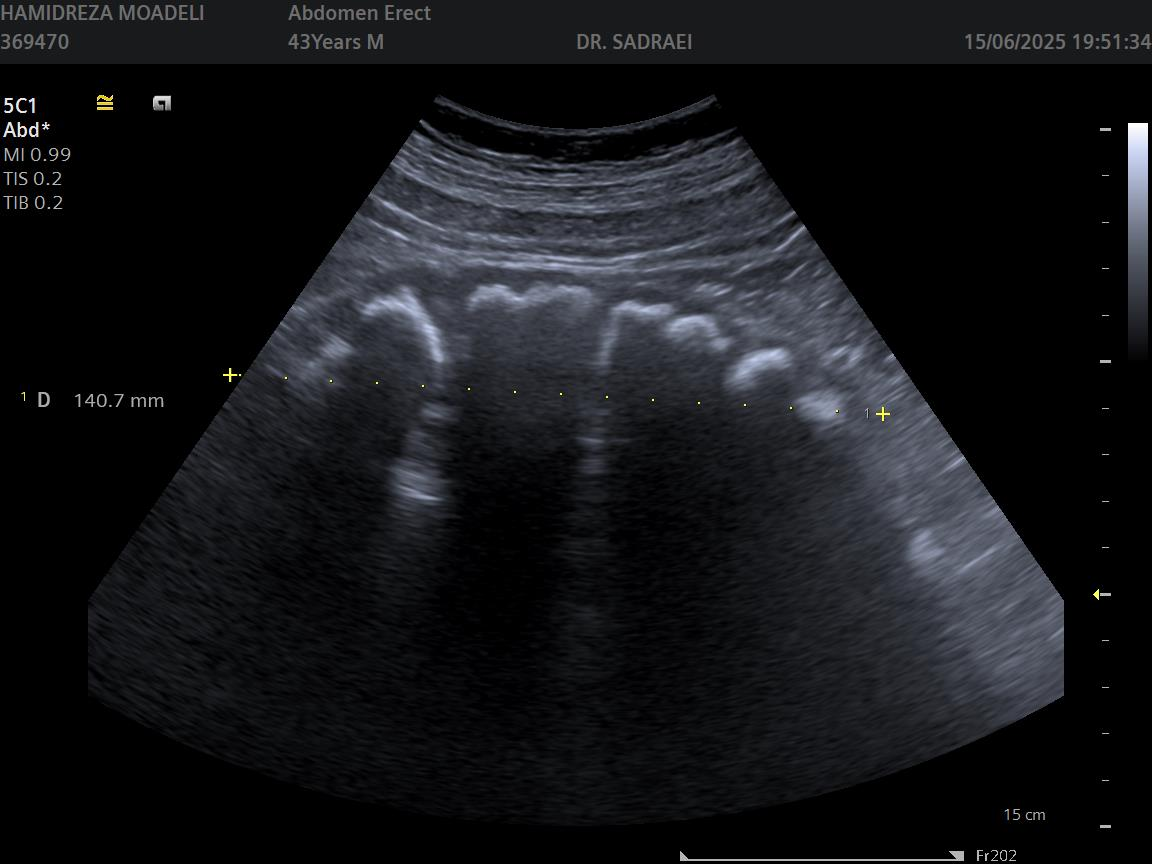

---

**[ MedGemma ]**

Based on the provided Sono image, here are the main measurements indicated by 'D' in mm:

*   **1 D 140.7 mm:** This measurement appears to be the **transverse diameter** of the **liver**.

**Summary:**

The image shows a transverse view of the abdomen, likely focusing on the liver. The measurement of 140.7 mm represents the width of the liver across its long axis. This is a common measurement used in abdominal ultrasound to assess liver size and morphology.

---

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944748305885162.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944746489343644.jpg


---

**[ User ]**

Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary

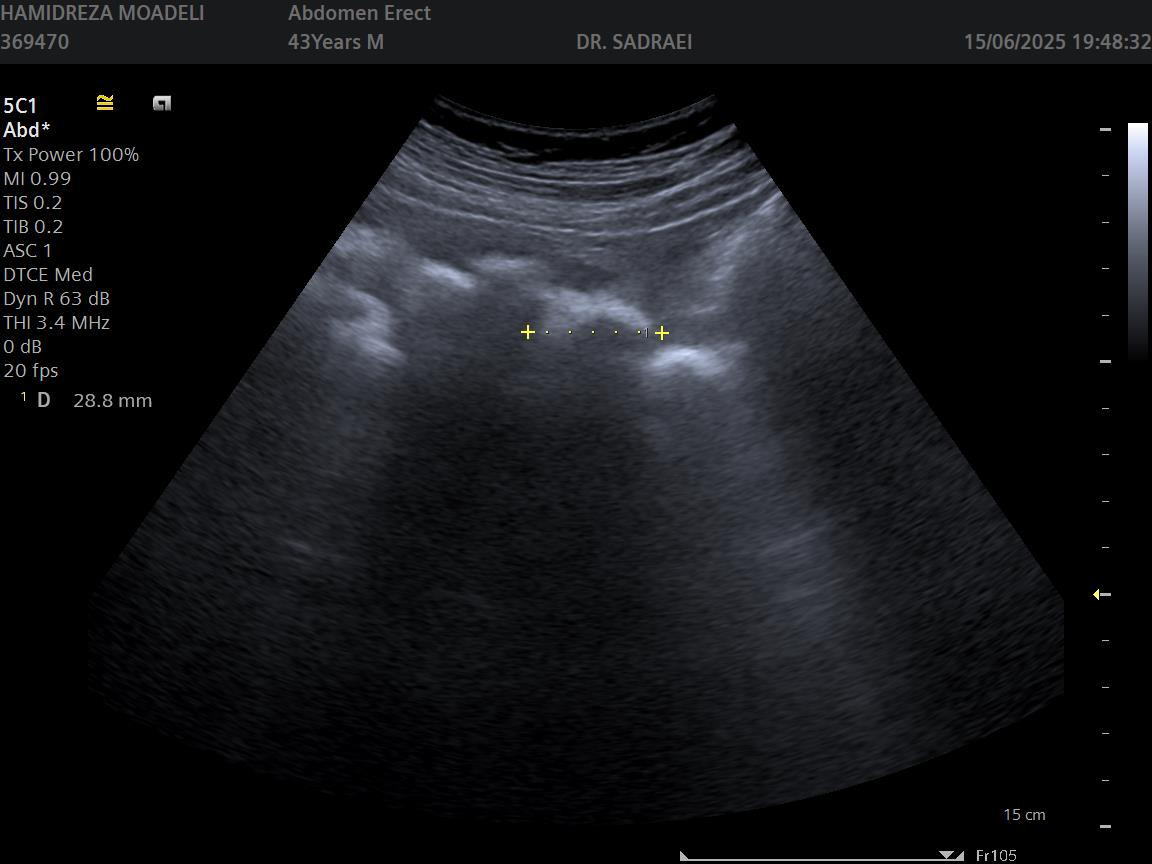

---

**[ MedGemma ]**

Based on the provided Sono image, here are the main measurements indicated by 'D' in mm:

*   **28.8 mm:** This measurement is located in the lower part of the image, near the bottom edge. It appears to be a measurement of the **renal pelvis**.

**Summary:**

The image shows a transverse view of the abdomen, likely focusing on the kidneys. The measurement of 28.8 mm is likely related to the size of the renal pelvis, which is the lower part of the kidney where urine collects before flowing into the ureter. This measurement could indicate a normal or potentially enlarged renal pelvis, requiring further clinical correlation.

---

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944746489343644.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944748114112083.jpg


---

**[ User ]**

Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary

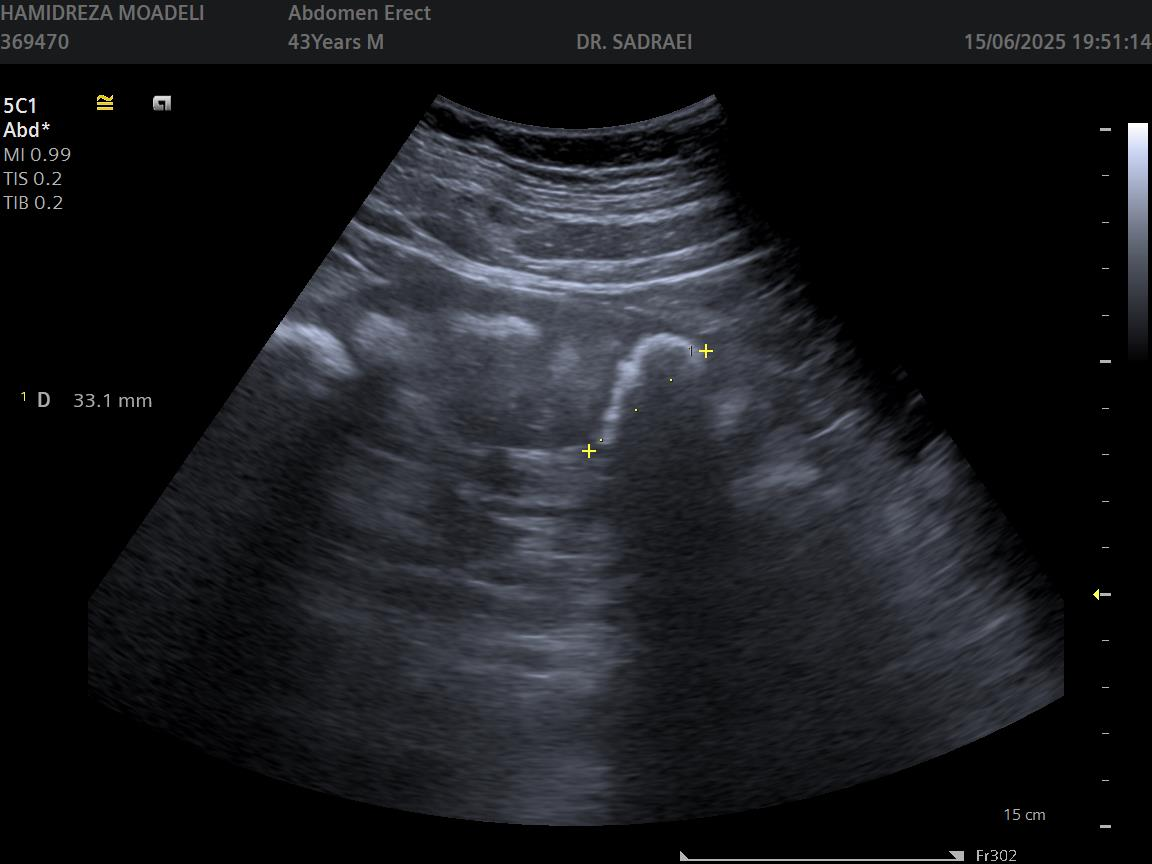

---

**[ MedGemma ]**

Based on the provided Sono image, here are the main measurements indicated by 'D' in mm:

*   **33.1 mm:** This measurement is located in the right side of the image, near the midline. It appears to be a measurement of the **right kidney**.

**Summary:**

The image shows a transverse view of the abdomen, likely focusing on the kidneys. The measurement of 33.1 mm is likely the **right kidney length**. The other measurements are not clearly indicated by 'D' in the image provided.

---

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944748114112083.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944747788985117.jpg


---

**[ User ]**

Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary

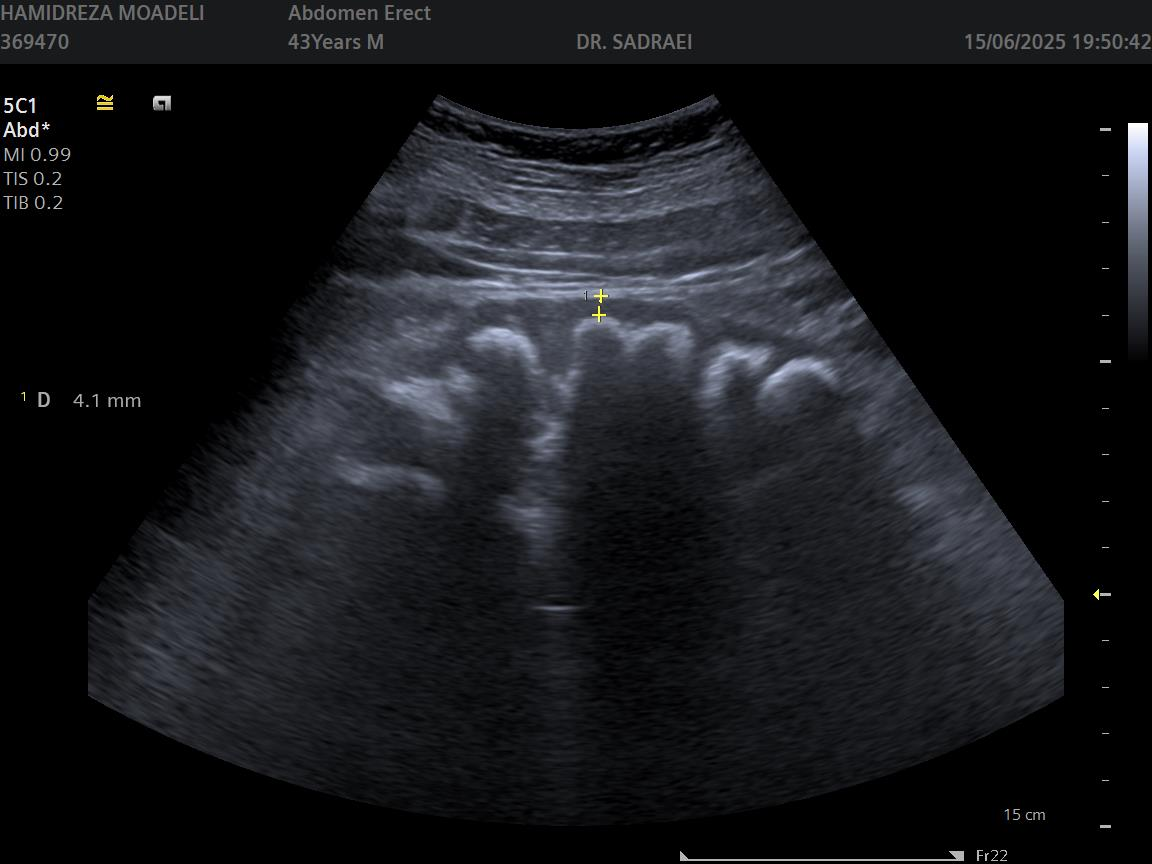

---

**[ MedGemma ]**

Based on the provided Sono image, here are the main measurements indicated by 'D' in mm:

*   **4.1 mm:** This measurement is located near the right side of the image, slightly above the midline. It appears to be a small, rounded structure.

**Guess what these measurements represent:**

*   **4.1 mm:** This measurement likely represents a small cyst or fluid collection within the liver parenchyma.

**Summary:**

The image shows a transverse view of the abdomen, likely focusing on the liver. There is a small, rounded structure measuring approximately 4.1 mm, which could represent a small cyst or fluid collection within the liver. The rest of the image shows normal liver parenchyma.

---

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944747788985117.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944747902333880.jpg


---

**[ User ]**

Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary

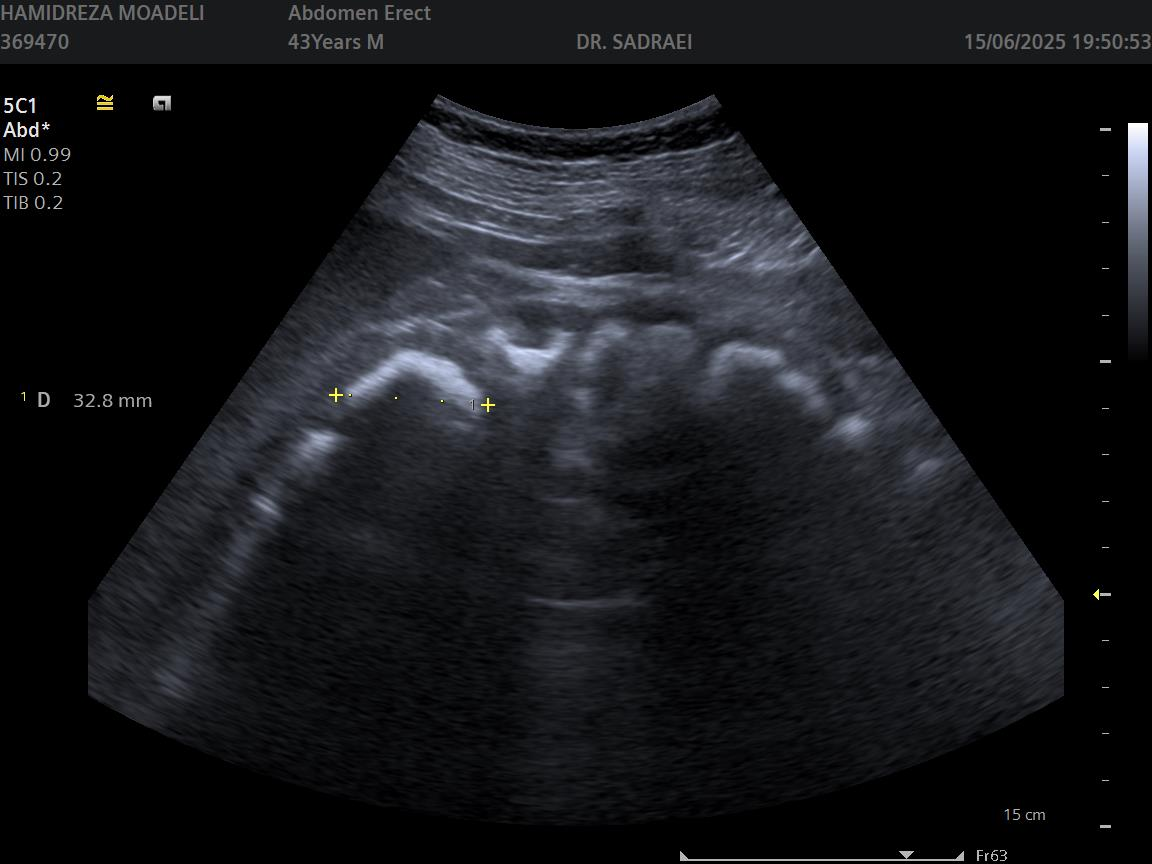

---

**[ MedGemma ]**

Based on the provided Sono image, here are the main measurements indicated by 'D' in mm:

*   **32.8 mm:** This measurement is located in the **Abdomen** region, specifically within the **Transverse** plane. It appears to be a measurement of the **renal pelvis**.

**Summary:**

The image shows a transverse view of the abdomen, likely focusing on the kidneys. The measurement of 32.8 mm is likely related to the size of the renal pelvis, which is a common measurement in abdominal ultrasound to assess kidney structure and potential abnormalities.

---

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944747902333880.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944746303199295.jpg


---

**[ User ]**

Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary

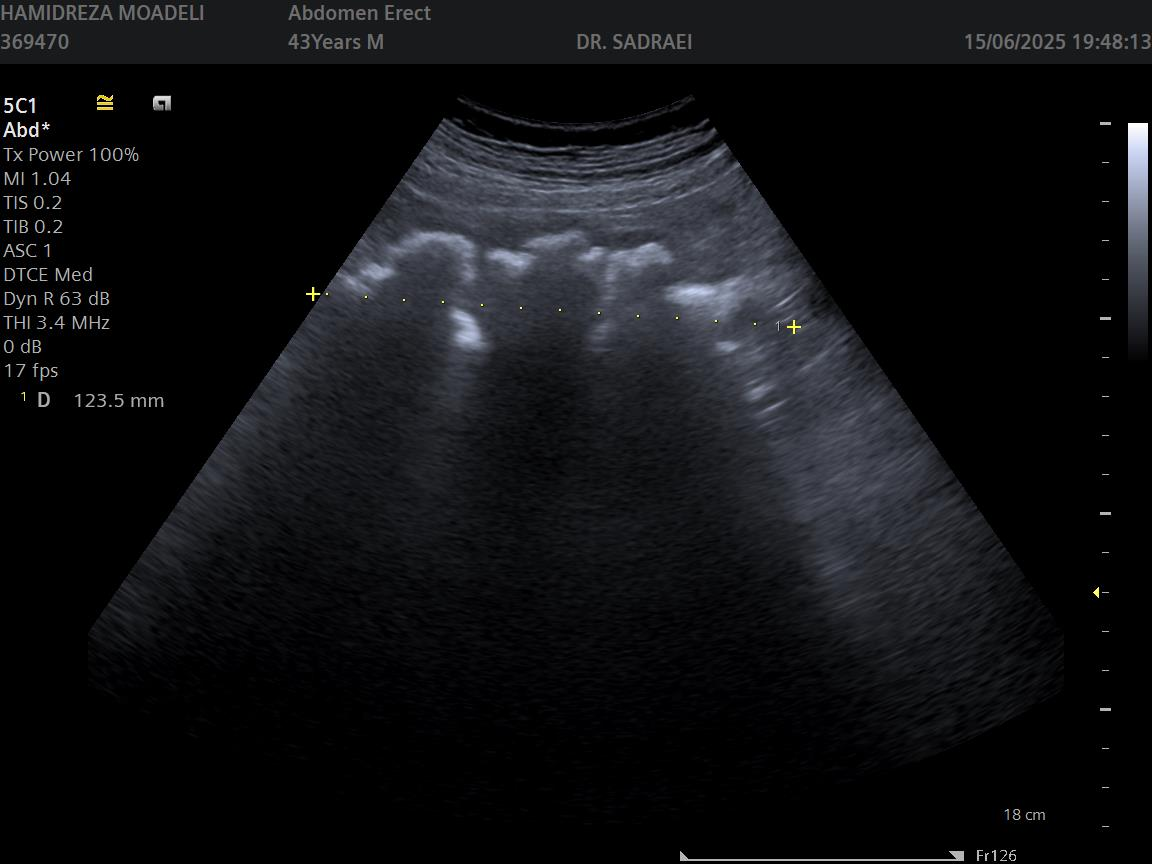

---

**[ MedGemma ]**

Based on the provided Sono image, here are the main measurements indicated by 'D' in mm:

*   **1 D 123.5 mm:** This measurement likely represents the **depth of the transducer** used for the ultrasound scan, indicating the distance between the transducer and the area being imaged.

**Summary:**

The image shows a transverse view of the abdomen, likely focusing on the liver and adjacent structures. The measurement of 123.5 mm represents the depth of the ultrasound probe, which is a technical parameter of the imaging system and not a measurement of the anatomical structures being visualized.

---

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944746303199295.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944752204281831.jpg


---

**[ User ]**

Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary

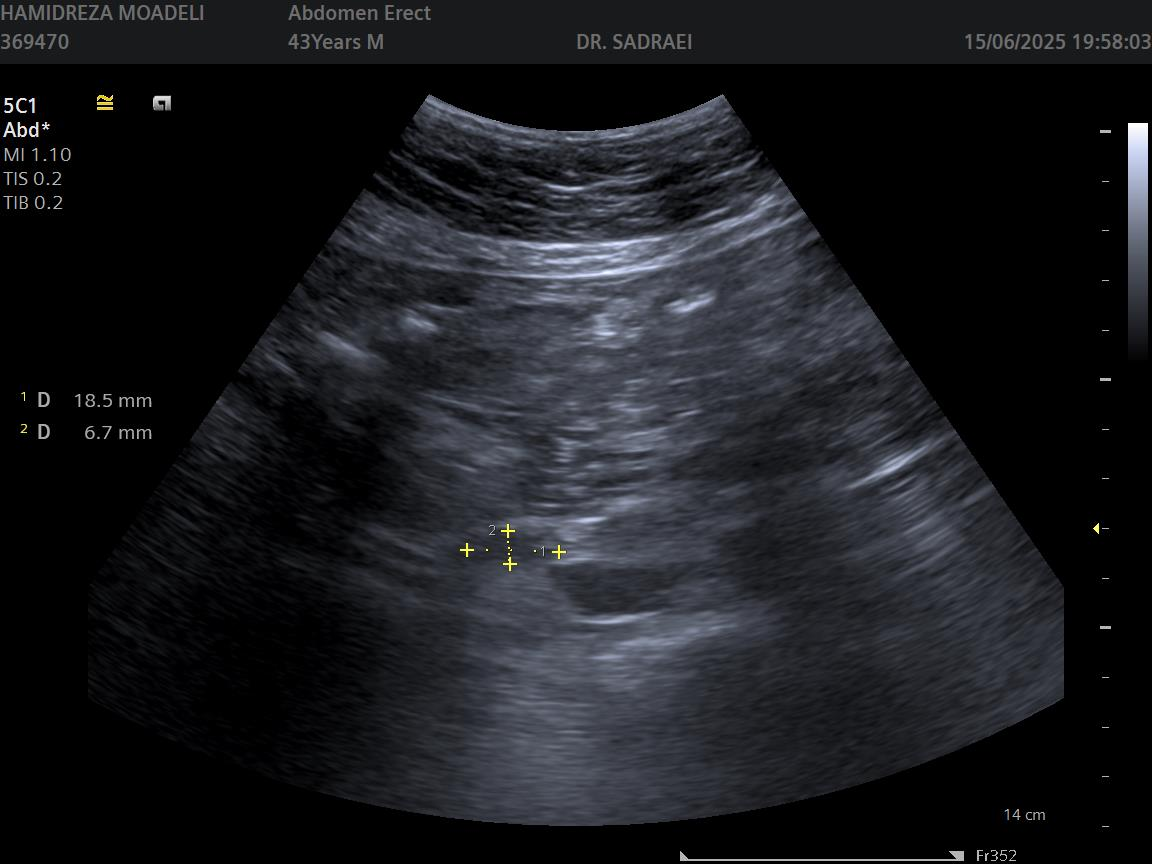

---

**[ MedGemma ]**

Based on the provided Sono image, here are the main measurements indicated by 'D' in mm:

*   **1 D: 18.5 mm**
*   **2 D: 6.7 mm**

These measurements likely represent the **transverse diameter** of the **renal pelvis** in the kidneys. The renal pelvis is the funnel-shaped structure at the bottom of the kidney where urine collects before flowing into the ureter. The measurements are taken across the width of the pelvis.

**Summary:** The image shows a transverse view of the abdomen, likely focusing on the kidneys. The measurements indicate the transverse diameters of the renal pelvis, which are 18.5 mm and 6.7 mm.

---

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944752204281831.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944747680676195.jpg


---

**[ User ]**

Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary

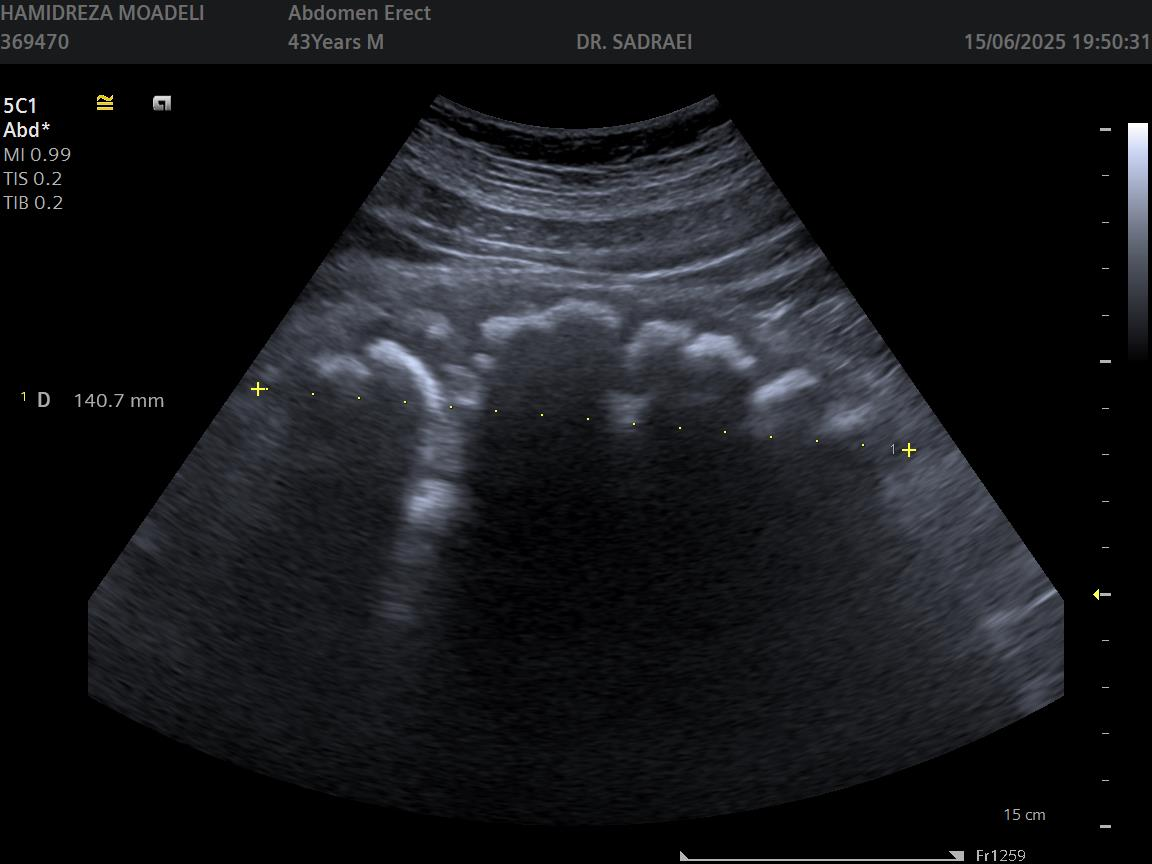

---

**[ MedGemma ]**

Based on the provided ultrasound image, here are the main measurements indicated by 'D' in mm:

*   **1 D 140.7 mm:** This measurement likely represents the **transverse diameter of the gallbladder**. The gallbladder is the organ located beneath the liver.

**Summary:**

The image shows a transverse view of the abdomen, likely focusing on the gallbladder. The measurement of 140.7 mm corresponds to the width of the gallbladder.

---

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944747680676195.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944748951002993.jpg


---

**[ User ]**

Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary

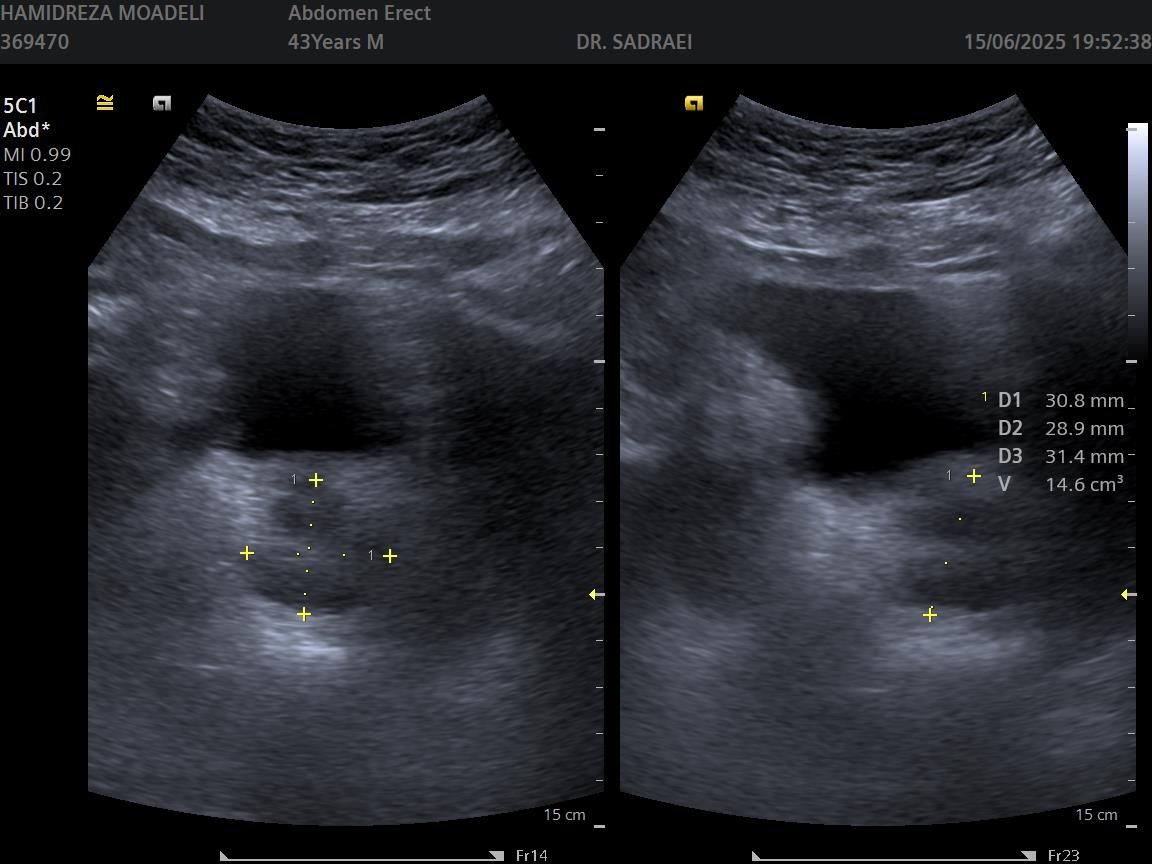

---

**[ MedGemma ]**

Based on the provided Sono image, here are the main measurements indicated by 'D' in mm:

*   **D1:** 30.8 mm
*   **D2:** 28.9 mm
*   **D3:** 31.4 mm
*   **V:** 14.6 mm

These measurements likely represent the **transverse diameters of the uterine body (fundus and body)**, which are commonly used to assess the uterine size and morphology in pelvic ultrasound imaging.

**Summary:** The image shows a transverse view of the uterus. The transverse diameters of the uterine body (D1, D2, D3) are approximately 30.8 mm, 28.9 mm, and 31.4 mm, respectively. The vertical diameter (V) is approximately 14.6 mm. These measurements are used to evaluate the uterine size and shape.

---

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Both `max_new_tokens` (=1300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944748951002993.jpg


Processed image: /content/drive/MyDrive/my_health/images/sono_1404/133944746816445808.jpg


---

**[ User ]**

Describe  main measurements only measured and indicated by 'D' ** 'mm' in this Sono image in bullet points format and guess what these measurements represent and then provide a summary

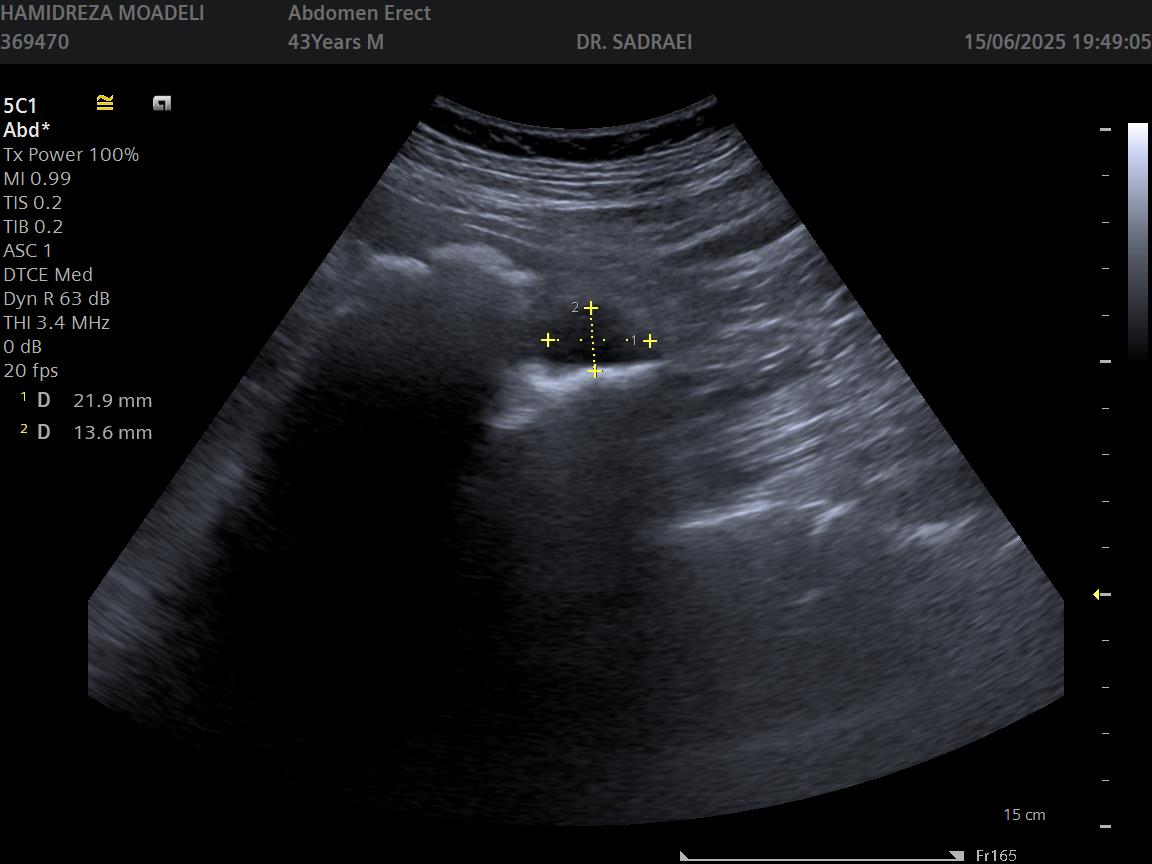

---

**[ MedGemma ]**

Based on the provided Sono image, here are the main measurements indicated by 'D' in mm:

*   **2 D 21.9 mm:** This measurement likely represents the **transverse diameter** of the **renal pelvis** or the **renal collecting system**.
*   **2 D 13.6 mm:** This measurement likely represents the **longitudinal diameter** of the **renal pelvis** or the **renal collecting system**.

**Summary:**

The image shows a transverse view of the abdomen, likely focusing on the kidneys. The measurements indicate the diameters of the renal collecting system (renal pelvis). The values are within a reasonable range for these structures, although further clinical context is needed for definitive interpretation.

---

Finished processing image: /content/drive/MyDrive/my_health/images/sono_1404/133944746816445808.jpg




In [69]:
for image_path in images_path:
    print(f"Processed image: {image_path}")
    interpret_image(image_path, prompt)
    print(f"Finished processing image: {image_path}\n\n")
